# 1. Importing Libraries

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.7 MB/s eta 0:00:00


In [2]:
!pip install transformers

In [137]:
import requests
import json
import pandas as pd
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import time
import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SimpleRNN, GRU, Bidirectional
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, BertForSequenceClassification
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from scipy.special import softmax

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# 2. Loading the Dataset

We take the first 100,000 rows from the elite_persona part10 subset and load into a Pandas dataframe

In [5]:
url = "https://huggingface.co/datasets/proj-persona/PersonaHub/resolve/main/ElitePersonas/elite_personas.part10.jsonl"

response = requests.get(url, stream=True)
response.raise_for_status()

data_list = []

for i, line in enumerate(response.iter_lines()):
    if i >= 100000:
        break
    if line:
        data_list.append(json.loads(line.decode('utf-8')))

df = pd.DataFrame(data_list)

print(f"DataFrame shape: {df.shape}")

df.head()

DataFrame shape: (100000, 6)


,persona,general domain (top 1 percent),specific domain (top 1 percent),general domain (top 0.1 percent),specific domain (top 0.1 percent),specific domain (top 0.0.1 percent)
0,A science educator who aims to inspire and mot...,education,science education,None,None,NaN
1,A birdwatcher who is interested in the surviva...,biology,ornithology,None,None,NaN
2,A financial analyst who is familiar with the c...,finance,None,None,None,NaN
3,A team of engineers from Princeton University ...,Materials Science/Engineering,Piezoelectric Materials and Energy Harvesting,None,Piezoelectric Materials and Energy Harvesting,NaN
4,A teacher who uses social media to teach stude...,None,educational technology,None,None,NaN


We only keep the 'persona' and 'general domain (top 1 percent)' columns for the project


In [6]:
df = df[['persona', 'general domain (top 1 percent)']]

print(f"Updated DataFrame shape: {df.shape}")
display(df.head())

Updated DataFrame shape: (100000, 2)


,persona,general domain (top 1 percent)
0,A science educator who aims to inspire and mot...,education
1,A birdwatcher who is interested in the surviva...,biology
2,A financial analyst who is familiar with the c...,finance
3,A team of engineers from Princeton University ...,Materials Science/Engineering
4,A teacher who uses social media to teach stude...,None


# 3. Initial Data Statistics

Identifying if there are any missing values in the general domain (top 1 percent) column

In [7]:
missing_count_domain = df['general domain (top 1 percent)'].isna().sum()
print(f"Number of missing values in 'general domain (top 1 percent)': {missing_count_domain}")

Number of missing values in 'general domain (top 1 percent)': 0


Identifying if there are any missing values in the persona column

In [8]:
missing_count_persona = df['persona'].isna().sum()
print(f"Number of missing values in 'persona': {missing_count_persona}")

Number of missing values in 'persona': 0


Identifying if there are any literal 'None' string in the general domain (top 1 percent) column

In [9]:
string_none_count_domain = df['general domain (top 1 percent)'].isin(['None', 'none', 'NONE']).sum()
print(f"Number of 'None' values in 'general domain (top 1 percent)': {string_none_count_domain}")

Number of 'None' values in 'general domain (top 1 percent)': 16768


Identifying if there are any literal 'None' string in the persona column

In [10]:
string_none_count_persona = df['persona'].isin(['None', 'none', 'NONE']).sum()
print(f"Number of 'None' values in 'persona': {string_none_count_persona}")

Number of 'None' values in 'persona': 0


Identifying if there are any duplicate texts in the 'persona' column

In [11]:
duplicate_count = df.duplicated(subset=['persona']).sum()
print(f"Number of duplicate texts: {duplicate_count}")

Number of duplicate texts: 0


Identifying the number of total unique classes in the 'general domain (top 1 percent)' column

In [12]:
num_unique = df['general domain (top 1 percent)'].nunique()
print(f"Total unique classes: {num_unique}")

Total unique classes: 2353


# 4. Data Cleaning and Class Selection

Removing the literal string "None", "none" and "NONE" from the 'general domain (top 1 percent)' column

In [13]:
df_cleaned = df[~df["general domain (top 1 percent)"].isin(["None", "none", "NONE"])].copy()

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")

Original row count: 100000
Cleaned row count: 83232


Convert 'general domain (top 1 percent)' column to lowercase and remove accidental leading/trailing spaces

In [14]:
df_cleaned["general domain (top 1 percent)"] = df_cleaned["general domain (top 1 percent)"].str.lower().str.strip()

Remove non-English texts from the 'persona' column

In [15]:
def is_english_ascii(text, threshold=0.99):
    if not isinstance(text, str) or not text.strip():
        return False

    allowed = set(string.ascii_letters + string.digits + string.punctuation + " \n\r\t")

    ascii_chars = sum(1 for char in text if char in allowed)
    ratio = ascii_chars / len(text)

    return ratio >= threshold

is_english_mask = df_cleaned["persona"].apply(is_english_ascii)
df_cleaned_english = df_cleaned[is_english_mask].copy()

print(f"Removed non-English rows: {len(df_cleaned) - len(df_cleaned_english)}")

Removed non-English rows: 116


In [16]:
df_removed = df_cleaned[~is_english_mask].copy()
text = df_removed['persona'].iloc[18]
print(f"Example of a removed non-English row: {text}")

Example of a removed non-English row: A隧道防火门专家，专注于隧道防火门的设计、安装和测试，确保隧道内的防火、烟气和烟雾不会扩散到其他部分，如舱室或逃生路线。他的专业知识包括防火门的性能测试，确保其能够承受火灾、烟雾和烟气，同时能够抵抗污染化学品的腐蚀。他的产品通过了国际认可的RWS曲线测试，测试温度不应超过250度，混凝土与防火保护的接口失效标准为380度。


Find out the top 10 classes in the dataset

In [17]:
top_10_classes = df_cleaned_english["general domain (top 1 percent)"].value_counts().head(10)
top_10_names = top_10_classes.index.tolist()

print("Top 10 Classes:")
display(top_10_classes)

Top 10 Classes:


,count
general domain (top 1 percent),
biology,7264
medicine,6805
history,6485
engineering,6392
education,3940
computer science,3815
environmental science,3778
physics,2107
psychology,2088


Only keep the rows where the general domain contains a class from the top 10 classes

In [18]:
df_top10 = df_cleaned_english[df_cleaned_english["general domain (top 1 percent)"].isin(top_10_names)].copy()

Find the minimum class count from the top 10 classes

In [19]:
min_class_count = df_top10["general domain (top 1 percent)"].value_counts().min()

Perform random undersampling to balance the data

In [20]:
df_balanced = (
    df_top10.groupby("general domain (top 1 percent)")
    .sample(n=min_class_count, random_state=42)
    .reset_index(drop=True)
)

print(f"Balanced dataset row count: {len(df_balanced)}")
print()
print("Balanced Class Distribution:")
display(df_balanced["general domain (top 1 percent)"].value_counts())

Balanced dataset row count: 17760

Balanced Class Distribution:


,count
general domain (top 1 percent),
biology,1776
computer science,1776
education,1776
engineering,1776
environmental science,1776
history,1776
medicine,1776
physics,1776
psychology,1776


# 5. Exploratory Data Analysis (EDA)

Dataset Cleaning & Reduction Pipeline Statistics

In [21]:
stats_data = {
    "Stage": [
        "Initial Loaded Subset",
        "After Dropping NaN/None in Target",
        "After Top 10 Class Filtering",
        "After Undersampling (Balanced)",
    ],
    "Row Count": [
        len(df),
        len(df_cleaned),
        len(df_top10),
        len(df_balanced),
    ],
}

stats_df = pd.DataFrame(stats_data)
stats_df["% Retained (of Initial)"] = (
    stats_df["Row Count"] / len(df) * 100
).round(2)

display(stats_df)

,Stage,Row Count,% Retained (of Initial)
0,Initial Loaded Subset,100000,100.00
1,After Dropping NaN/None in Target,83232,83.23
2,After Top 10 Class Filtering,44450,44.45
3,After Undersampling (Balanced),17760,17.76


Overall Document Length Statistics (Word Count)

In [22]:
df_balanced["word_count"] = df_balanced["persona"].apply(
    lambda x: len(str(x).split())
)

doc_stats = {
    "Metric": ["Min Words", "Max Words", "Mean Words", "Median Words", "Std Dev"],
    "Value": [
        df_balanced["word_count"].min(),
        df_balanced["word_count"].max(),
        round(df_balanced["word_count"].mean(), 2),
        df_balanced["word_count"].median(),
        round(df_balanced["word_count"].std(), 2),
    ],
}

display(pd.DataFrame(doc_stats))

,Metric,Value
0,Min Words,11.00
1,Max Words,463.00
2,Mean Words,92.86
3,Median Words,91.00
4,Std Dev,26.24


Per-Class Document Length Statistics

In [23]:
class_doc_stats = (
    df_balanced.groupby("general domain (top 1 percent)")["word_count"]
    .agg(["count", "min", "max", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

display(class_doc_stats)

,general domain (top 1 percent),count,min,max,mean,median,std
0,biology,1776,18,211,85.19,83.0,22.64
1,computer science,1776,28,323,93.14,90.0,26.82
2,education,1776,13,237,100.04,97.0,29.08
3,engineering,1776,18,298,94.16,93.0,25.28
4,environmental science,1776,11,215,96.90,95.0,25.03
5,history,1776,15,345,95.40,93.0,27.54
6,medicine,1776,13,225,87.16,85.0,24.94
7,physics,1776,23,463,88.64,87.0,25.59
8,psychology,1776,16,267,92.38,90.0,25.25
9,public health,1776,14,219,95.59,93.0,26.08


Initial Class Distribution vs Balanced Class Distribution

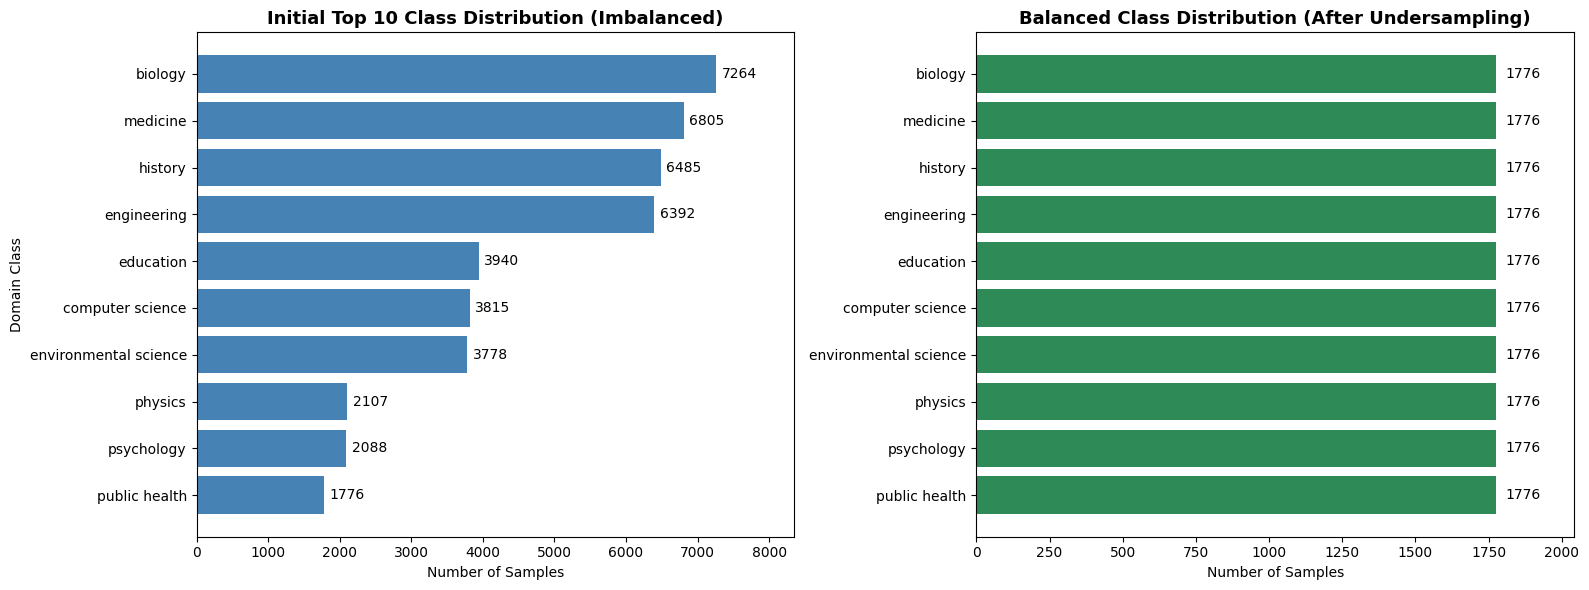

In [24]:
counts_initial = df_top10["general domain (top 1 percent)"].value_counts().loc[top_10_names]
counts_balanced = df_balanced["general domain (top 1 percent)"].value_counts().loc[top_10_names]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(counts_initial.index, counts_initial.values, color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Initial Top 10 Class Distribution (Imbalanced)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Domain Class")
axes[0].set_xlim(0, counts_initial.max() * 1.15)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(width + 80, bar.get_y() + bar.get_height() / 2, f"{int(width)}", va="center", fontsize=10)


bars2 = axes[1].barh(counts_balanced.index, counts_balanced.values, color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title("Balanced Class Distribution (After Undersampling)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Samples")
axes[1].set_xlim(0, counts_balanced.max() * 1.15)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 30, bar.get_y() + bar.get_height() / 2, f"{int(width)}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

Overall Document Length Distribution and Word Count Distribution by Domain

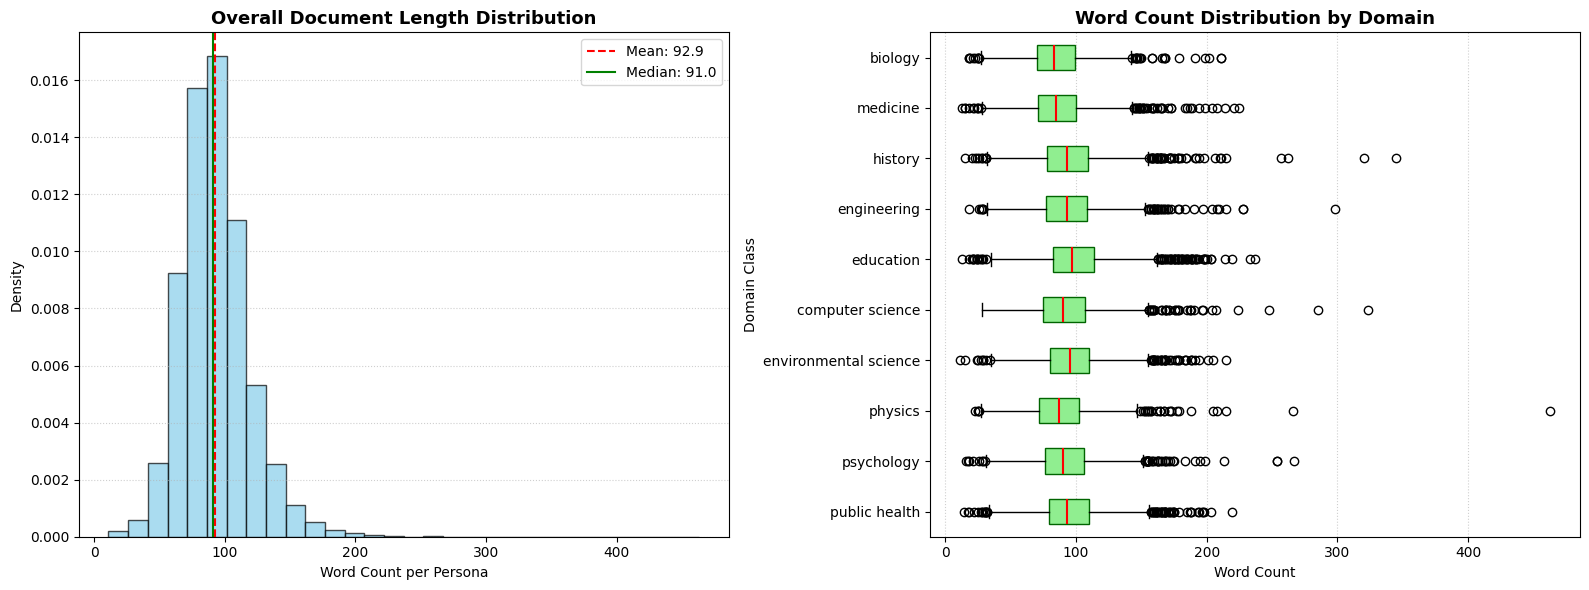

In [25]:
if "word_count" not in df_balanced.columns:
    df_balanced["word_count"] = df_balanced["persona"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(
    df_balanced["word_count"],
    bins=30,
    color="skyblue",
    edgecolor="black",
    density=True,
    alpha=0.7
)

mean_len = df_balanced["word_count"].mean()
median_len = df_balanced["word_count"].median()

axes[0].axvline(mean_len, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_len:.1f}")
axes[0].axvline(median_len, color="green", linestyle="-", linewidth=1.5, label=f"Median: {median_len:.1f}")

axes[0].set_title("Overall Document Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Word Count per Persona")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

domain_data = [
    df_balanced[df_balanced["general domain (top 1 percent)"] == domain]["word_count"].values
    for domain in top_10_names
]

axes[1].boxplot(
    domain_data,
    orientation="horizontal",
    tick_labels=top_10_names,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen", color="darkgreen"),
    medianprops=dict(color="red", linewidth=1.5)
)
axes[1].invert_yaxis()
axes[1].set_title("Word Count Distribution by Domain", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Domain Class")
axes[1].grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

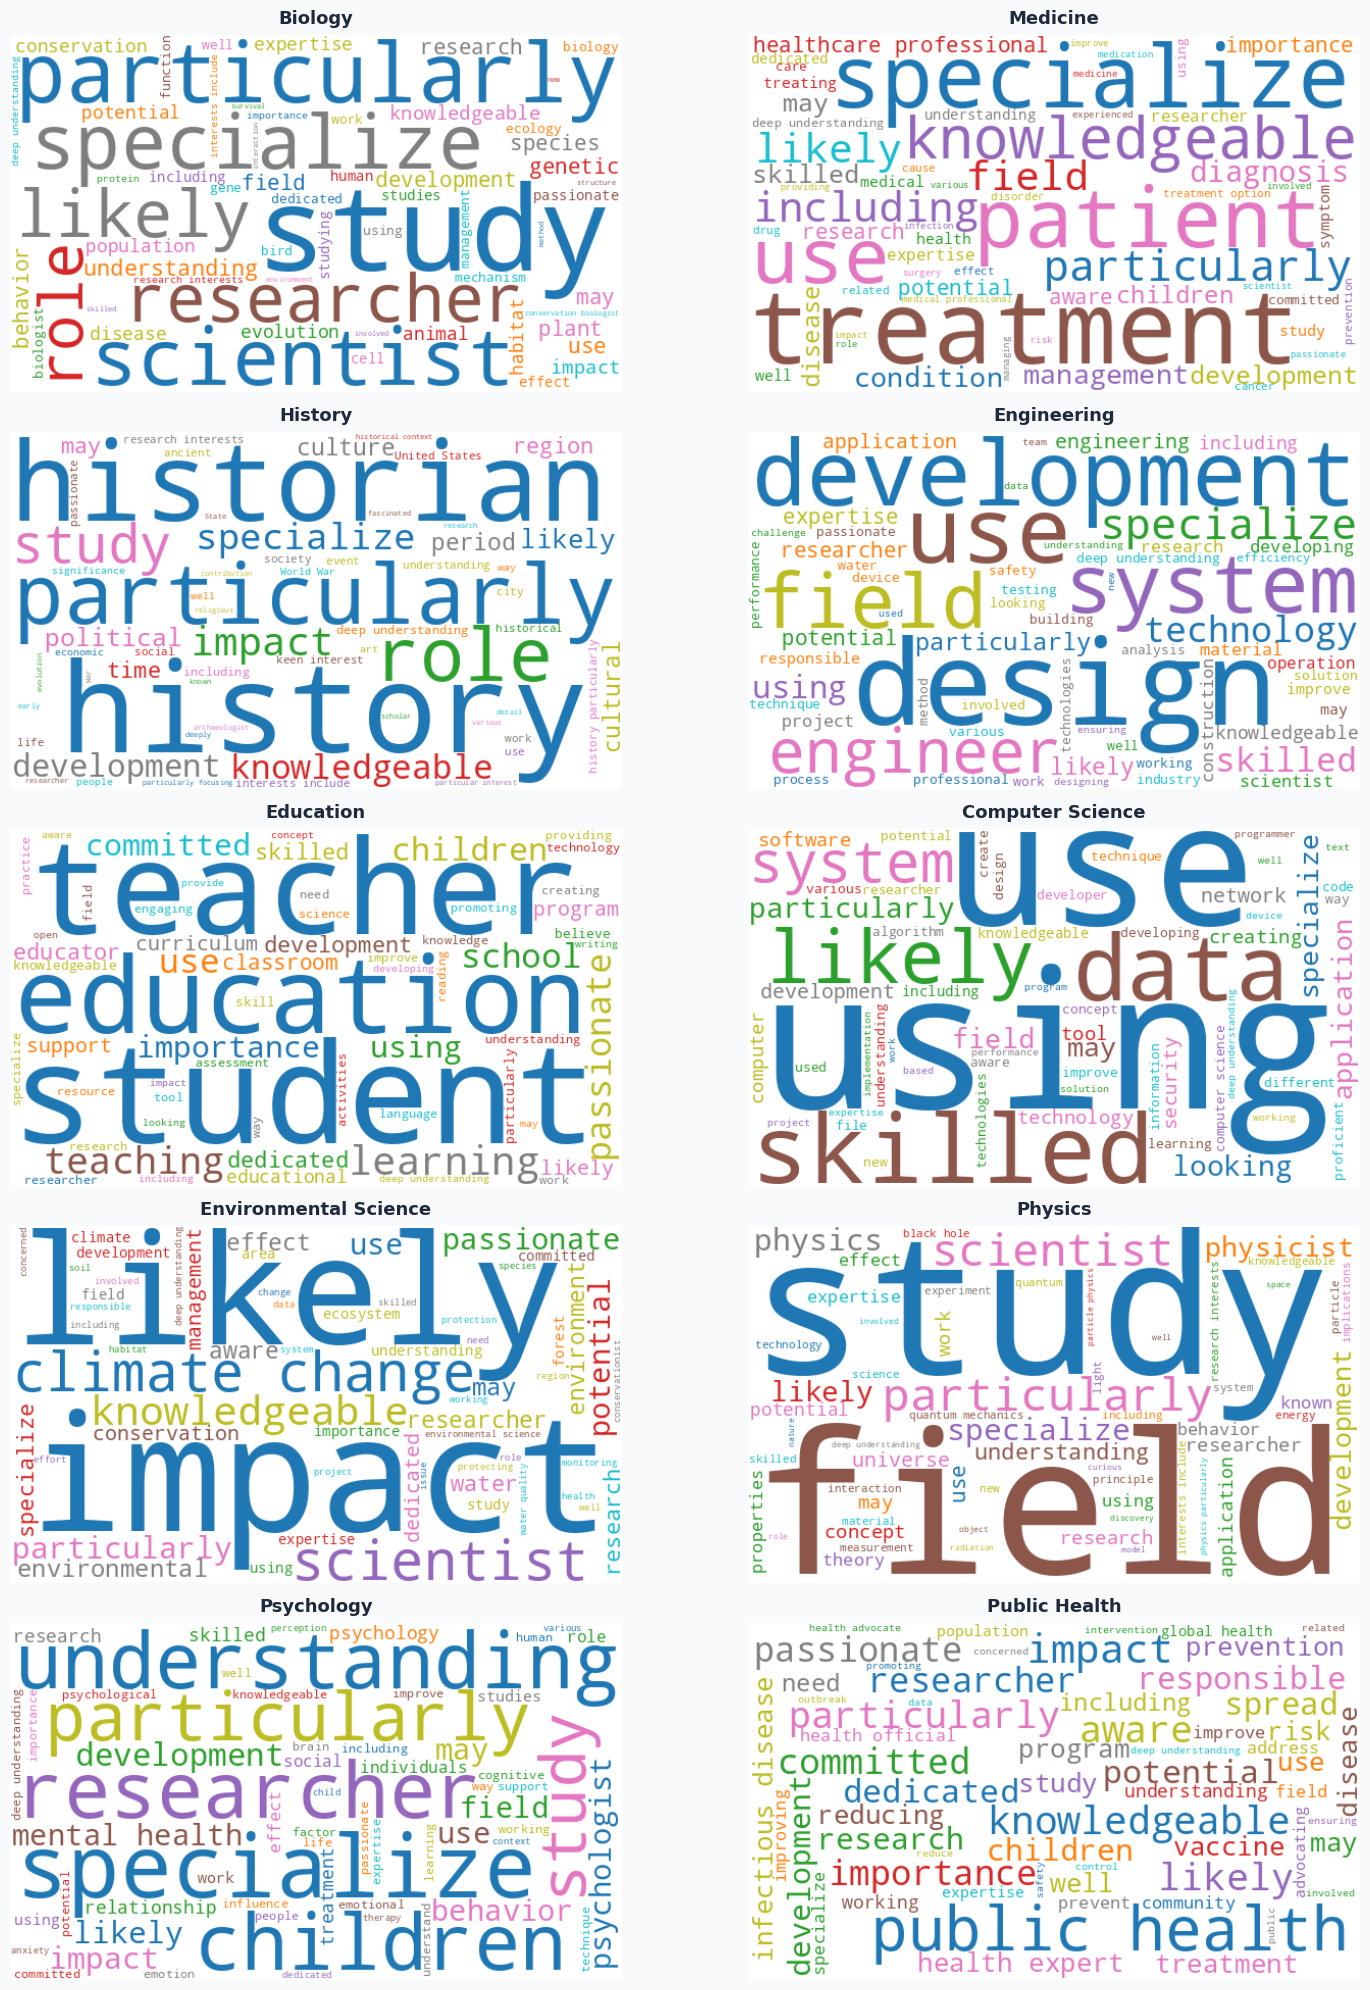

In [26]:
custom_stopwords = set(STOPWORDS).union({
    "persona", "aims", "interested", "familiar", "someone", "individual",
    "person", "works", "user", "focuses", "background", "experience"
})

fig, axes = plt.subplots(5, 2, figsize=(16, 20), facecolor="#F8FAFC")
axes = axes.flatten()

for i, domain in enumerate(top_10_names):

    text_data = " ".join(
        df_balanced[df_balanced["general domain (top 1 percent)"] == domain]["persona"].astype(str)
    )

    wc = WordCloud(
        stopwords=custom_stopwords,
        background_color="white",
        colormap="tab10",
        max_words=60,
        random_state=42,
        width=600,
        height=350,
        contour_width=1,
        contour_color="#CBD5E1"
    ).generate(text_data)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(domain.title(), fontsize=13, fontweight="bold", pad=8, color="#1E293B")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 6. Label Encoding

Target Class to Integer Mapping

In [27]:
label_encoder = LabelEncoder()


df_balanced["label"] = label_encoder.fit_transform(df_balanced["general domain (top 1 percent)"])


label_mapping = pd.DataFrame({
    "Class Name": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

display(label_mapping)

,Class Name,Encoded Label
0,biology,0
1,computer science,1
2,education,2
3,engineering,3
4,environmental science,4
5,history,5
6,medicine,6
7,physics,7
8,psychology,8
9,public health,9


# 7. Data Splitting

In [28]:
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.30,
    random_state=42,
    stratify=df_balanced["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train Set: {train_df.shape[0]} rows ({train_df.shape[0]/len(df_balanced):.1%})")
print(f"Validation Set: {val_df.shape[0]} rows ({val_df.shape[0]/len(df_balanced):.1%})")
print(f"Test Set: {test_df.shape[0]} rows ({test_df.shape[0]/len(df_balanced):.1%})")

Train Set: 12432 rows (70.0%)
Validation Set: 2664 rows (15.0%)
Test Set: 2664 rows (15.0%)


In [29]:
y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

Convert to Numpy Array for Better Fit on Keras

In [30]:
y_train_num = np.array(y_train)
y_val_num = np.array(y_val)
y_test_num = np.array(y_test)

# 8. Data Preprocessing & Tokenization

Heavy Data Preprocessing (lowercased, punctuation and digits stripped, stopwords removed, lemmatized)

In [31]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def apply_heavy_preprocessing(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

Light Data Preprocessing (whitespace normalization only, preserving casing, punctuation and word order)

In [32]:
def apply_light_preprocessing(text):
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

Apply both Preprocessing techniques

In [33]:
for d in [train_df, val_df, test_df]:
    d['text_heavy'] = d['persona'].apply(apply_heavy_preprocessing)
    d['text_light'] = d['persona'].apply(apply_light_preprocessing)

display(train_df[['persona', 'text_heavy', 'text_light']].head())

,persona,text_heavy,text_light
0,A mental health professional who specializes i...,mental health professional specializes working...,A mental health professional who specializes i...
1,A scientist who specializes in environmental h...,scientist specializes environmental health tox...,A scientist who specializes in environmental h...
2,A psychotherapist who uses narrative therapy t...,psychotherapist us narrative therapy help indi...,A psychotherapist who uses narrative therapy t...
3,A Microsoft Access database administrator who ...,microsoft access database administrator respon...,A Microsoft Access database administrator who ...
4,A physicist who specializes in the study of ro...,physicist specializes study rotational mechani...,A physicist who specializes in the study of ro...


# 9. Text Representation

## I. Using TF-IDF

In [34]:
vectorizer = TfidfVectorizer(max_features=5000)

With Heavy Data Preprocessing

In [35]:
X_train_tfidf_heavy = vectorizer.fit_transform(train_df["text_heavy"])
X_val_tfidf_heavy = vectorizer.transform(val_df["text_heavy"])
X_test_tfidf_heavy = vectorizer.transform(test_df["text_heavy"])

print(f"X_train_tfidf_heavy shape: {X_train_tfidf_heavy.shape}")
print(f"X_val_tfidf_heavy shape: {X_val_tfidf_heavy.shape}")
print(f"X_test_tfidf_heavy shape: {X_test_tfidf_heavy.shape}")



X_train_tfidf_heavy shape: (12432, 5000)
X_val_tfidf_heavy shape: (2664, 5000)
X_test_tfidf_heavy shape: (2664, 5000)


With Light Data Preprocessing

In [36]:
X_train_tfidf_light = vectorizer.fit_transform(train_df["text_light"])
X_val_tfidf_light = vectorizer.transform(val_df["text_light"])
X_test_tfidf_light = vectorizer.transform(test_df["text_light"])

print(f"X_train_tfidf_light shape: {X_train_tfidf_light.shape}")
print(f"X_val_tfidf_light shape: {X_val_tfidf_light.shape}")
print(f"X_test_tfidf_light shape: {X_test_tfidf_light.shape}")

X_train_tfidf_light shape: (12432, 5000)
X_val_tfidf_light shape: (2664, 5000)
X_test_tfidf_light shape: (2664, 5000)


## II. Using Word2Vec

With Heavy Data Preprocessing


In [37]:
train_tokens_w2v_heavy = [text_to_word_sequence(text) for text in train_df['text_heavy']]
val_tokens_w2v_heavy = [text_to_word_sequence(text) for text in val_df['text_heavy']]
test_tokens_w2v_heavy = [text_to_word_sequence(text) for text in test_df['text_heavy']]

In [38]:
w2v_model_heavy = Word2Vec(
    sentences = train_tokens_w2v_heavy,
    vector_size = 100,
    window = 5,
    min_count = 2,
    sg = 1,
    workers=4
)

With Light Data Preprocessing

In [39]:
train_tokens_w2v_light = [text_to_word_sequence(text) for text in train_df['text_light']]
val_tokens_w2v_light = [text_to_word_sequence(text) for text in val_df['text_light']]
test_tokens_w2v_light = [text_to_word_sequence(text) for text in test_df['text_light']]

In [40]:
w2v_model_light = Word2Vec(
    sentences = train_tokens_w2v_light,
    vector_size = 100,
    window = 5,
    min_count = 2,
    sg = 1,
    workers=4
)

## III. Using GloVe

In [42]:
def load_glove_model(glove_file):
    glove_dict = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.asarray(parts[1:], dtype='float32')
            glove_dict[word] = vector
    return glove_dict

glove_dictionary = load_glove_model('glove.6B.100d.txt')

With Heavy Data Preprocessing


In [43]:
train_tokens_glove_heavy = [text_to_word_sequence(text) for text in train_df['text_heavy']]
val_tokens_glove_heavy = [text_to_word_sequence(text) for text in val_df['text_heavy']]
test_tokens_glove_heavy = [text_to_word_sequence(text) for text in test_df['text_heavy']]

With Light Data Preprocessing


In [44]:
train_tokens_glove_light = [text_to_word_sequence(text) for text in train_df['text_light']]
val_tokens_glove_light = [text_to_word_sequence(text) for text in val_df['text_light']]
test_tokens_glove_light = [text_to_word_sequence(text) for text in test_df['text_light']]

## IV. Sequence Tokenization & Padding

In [45]:
VOCAB_SIZE = 10000
MAX_LEN = 150
OOV_TOKEN = "<OOV>"

With Heavy Data Preprocessing


In [46]:
tokenizer_heavy = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer_heavy.fit_on_texts(train_df['text_heavy'])

train_seq_heavy = pad_sequences(
    tokenizer_heavy.texts_to_sequences(train_df['text_heavy']),
    maxlen=MAX_LEN,
    padding='post'
)
val_seq_heavy = pad_sequences(
    tokenizer_heavy.texts_to_sequences(val_df['text_heavy']),
    maxlen=MAX_LEN,
    padding='post'
)
test_seq_heavy = pad_sequences(
    tokenizer_heavy.texts_to_sequences(test_df['text_heavy']),
    maxlen=MAX_LEN,
    padding='post'
)

With Light Data Preprocessing


In [47]:
tokenizer_light = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer_light.fit_on_texts(train_df['text_light'])

train_seq_light = pad_sequences(
    tokenizer_light.texts_to_sequences(train_df['text_light']),
    maxlen=MAX_LEN,
    padding='post'
)
val_seq_light = pad_sequences(
    tokenizer_light.texts_to_sequences(val_df['text_light']),
    maxlen=MAX_LEN,
    padding='post'
)
test_seq_light = pad_sequences(
    tokenizer_light.texts_to_sequences(test_df['text_light']),
    maxlen=MAX_LEN,
    padding='post'
)

## V. Pre-computing Embedding Matrices

In [48]:
def build_embedding_matrix(word_index, embedding_source, is_w2v=False):
    embedding_matrix = np.zeros((VOCAB_SIZE, 100))

    for word, i in word_index.items():
        if i >= VOCAB_SIZE:
            continue

        if is_w2v:
            if word in embedding_source.wv.key_to_index:
                embedding_matrix[i] = embedding_source.wv[word]
        else:
            if word in embedding_source:
                embedding_matrix[i] = embedding_source[word]

    return embedding_matrix

embedding_matrix_w2v_heavy = build_embedding_matrix(tokenizer_heavy.word_index, w2v_model_heavy, is_w2v=True)
embedding_matrix_w2v_light = build_embedding_matrix(tokenizer_light.word_index, w2v_model_light, is_w2v=True)

embedding_matrix_glove_heavy = build_embedding_matrix(tokenizer_heavy.word_index, glove_dictionary, is_w2v=False)
embedding_matrix_glove_light = build_embedding_matrix(tokenizer_light.word_index, glove_dictionary, is_w2v=False)

## VI. BERT Tokenization

In [49]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 150

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

For Heavy Data Preprocessing

In [50]:
train_encoded_heavy = tokenizer(
    train_df['text_heavy'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
train_input_ids_heavy = train_encoded_heavy['input_ids']
train_masks_heavy = train_encoded_heavy['attention_mask']

val_encoded_heavy = tokenizer(
    val_df['text_heavy'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
val_input_ids_heavy = val_encoded_heavy['input_ids']
val_masks_heavy = val_encoded_heavy['attention_mask']

test_encoded_heavy = tokenizer(
    test_df['text_heavy'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
test_input_ids_heavy = test_encoded_heavy['input_ids']
test_masks_heavy = test_encoded_heavy['attention_mask']

Preparing for Pytorch's version of BERT

In [51]:
train_dataset_heavy = Dataset.from_dict({
    'input_ids': train_input_ids_heavy,
    'attention_mask': train_masks_heavy,
    'label': y_train_num
})

val_dataset_heavy = Dataset.from_dict({
    'input_ids': val_input_ids_heavy,
    'attention_mask': val_masks_heavy,
    'label': y_val_num
})

test_dataset_heavy = Dataset.from_dict({
    'input_ids': test_input_ids_heavy,
    'attention_mask': test_masks_heavy,
    'label': y_test_num
})

For Light Data Preprocessing

In [52]:
train_encoded_light = tokenizer(
    train_df['text_light'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
train_input_ids_light = train_encoded_light['input_ids']
train_masks_light = train_encoded_light['attention_mask']

val_encoded_light = tokenizer(
    val_df['text_light'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
val_input_ids_light = val_encoded_light['input_ids']
val_masks_light = val_encoded_light['attention_mask']

test_encoded_light = tokenizer(
    test_df['text_light'].tolist(),
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='np'
)
test_input_ids_light = test_encoded_light['input_ids']
test_masks_light = test_encoded_light['attention_mask']

In [53]:
train_dataset_light = Dataset.from_dict({
    'input_ids': train_input_ids_light,
    'attention_mask': train_masks_light,
    'label': y_train_num
})

val_dataset_light = Dataset.from_dict({
    'input_ids': val_input_ids_light,
    'attention_mask': val_masks_light,
    'label': y_val_num
})

test_dataset_light = Dataset.from_dict({
    'input_ids': test_input_ids_light,
    'attention_mask': test_masks_light,
    'label': y_test_num
})

# 10. Comparison of Different Data Preprocessing Techniques on Different Text Representations

## I. On Logistic Regression

Comparing Heavy and Light Data Preprocessing on Logistic Regression using TF-IDF

In [54]:
lr_model_tfidf_heavy = LogisticRegression(max_iter=1000, random_state=42)
lr_model_tfidf_heavy.fit(X_train_tfidf_heavy, y_train)

y_pred_val_tfidf_heavy = lr_model_tfidf_heavy.predict(X_val_tfidf_heavy)
acc_val_tfidf_heavy = accuracy_score(y_val, y_pred_val_tfidf_heavy)
f1_val_tfidf_heavy = f1_score(y_val, y_pred_val_tfidf_heavy, average='weighted')

print(f"Accuracy: {acc_val_tfidf_heavy:.4f} | F1 Score: {f1_val_tfidf_heavy:.4f}")

Accuracy: 0.9159 | F1 Score: 0.9161


In [55]:
lr_model_tfidf_light = LogisticRegression(max_iter=1000, random_state=42)
lr_model_tfidf_light.fit(X_train_tfidf_light, y_train)

y_pred_val_tfidf_light = lr_model_tfidf_light.predict(X_val_tfidf_light)
acc_val_tfidf_light = accuracy_score(y_val, y_pred_val_tfidf_light)
f1_val_tfidf_light = f1_score(y_val, y_pred_val_tfidf_light, average='weighted')

print(f"Accuracy: {acc_val_tfidf_light:.4f} | F1 Score: {f1_val_tfidf_light:.4f}")

Accuracy: 0.9088 | F1 Score: 0.9089


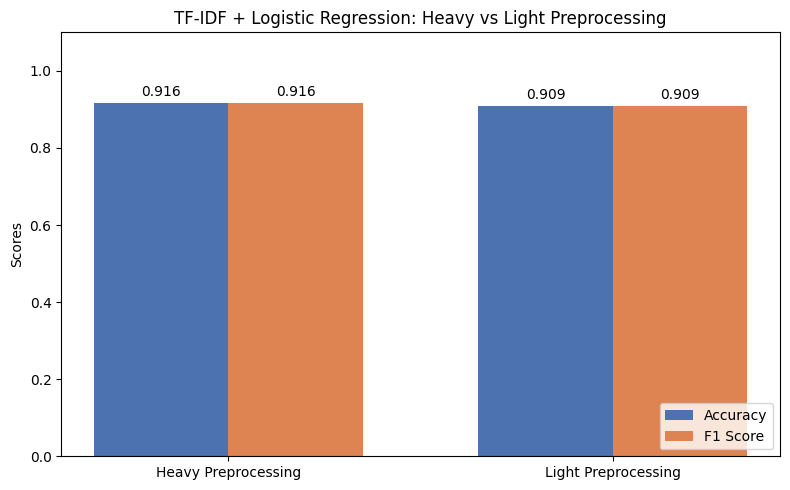

In [56]:
metrics_tfidf = {
    'Heavy Preprocessing': {'Accuracy': acc_val_tfidf_heavy, 'F1 Score': f1_val_tfidf_heavy},
    'Light Preprocessing': {'Accuracy': acc_val_tfidf_light, 'F1 Score': f1_val_tfidf_light}
}

labels = list(metrics_tfidf.keys())
accuracy_vals = [metrics_tfidf[label]['Accuracy'] for label in labels]
f1_vals = [metrics_tfidf[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores')
ax.set_title('TF-IDF + Logistic Regression: Heavy vs Light Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

Comparing Heavy and Light Data Preprocessing on Logistic Regression using Word2Vec

In [57]:
def get_w2v_document_vector(tokens, w2v_model, vector_size=100):
    valid_words = [word for word in tokens if word in w2v_model.wv.key_to_index]
    if not valid_words:
        return np.zeros(vector_size)
    return np.mean([w2v_model.wv[word] for word in valid_words], axis=0)

In [58]:
X_train_w2v_heavy = np.array([get_w2v_document_vector(t, w2v_model_heavy) for t in train_tokens_w2v_heavy])
X_val_w2v_heavy = np.array([get_w2v_document_vector(t, w2v_model_heavy) for t in val_tokens_w2v_heavy])
X_test_w2v_heavy = np.array([get_w2v_document_vector(t, w2v_model_heavy) for t in test_tokens_w2v_heavy])

X_train_w2v_light = np.array([get_w2v_document_vector(t, w2v_model_light) for t in train_tokens_w2v_light])
X_val_w2v_light = np.array([get_w2v_document_vector(t, w2v_model_light) for t in val_tokens_w2v_light])
X_test_w2v_light = np.array([get_w2v_document_vector(t, w2v_model_light) for t in test_tokens_w2v_light])

In [59]:
lr_model_w2v_heavy = LogisticRegression(max_iter=1000, random_state=42)
lr_model_w2v_heavy.fit(X_train_w2v_heavy, y_train)

y_pred_val_w2v_heavy = lr_model_w2v_heavy.predict(X_val_w2v_heavy)
acc_val_w2v_heavy = accuracy_score(y_val, y_pred_val_w2v_heavy)
f1_val_w2v_heavy = f1_score(y_val, y_pred_val_w2v_heavy, average='weighted')

print(f"Accuracy: {acc_val_w2v_heavy:.4f} | F1 Score: {f1_val_w2v_heavy:.4f}")

Accuracy: 0.9009 | F1 Score: 0.9008


In [60]:
lr_model_w2v_light = LogisticRegression(max_iter=1000, random_state=42)
lr_model_w2v_light.fit(X_train_w2v_light, y_train)

y_pred_val_w2v_light = lr_model_w2v_light.predict(X_val_w2v_light)
acc_val_w2v_light = accuracy_score(y_val, y_pred_val_w2v_light)
f1_val_w2v_light = f1_score(y_val, y_pred_val_w2v_light, average='weighted')

print(f"Accuracy: {acc_val_w2v_light:.4f} | F1 Score: {f1_val_w2v_light:.4f}")

Accuracy: 0.8840 | F1 Score: 0.8840


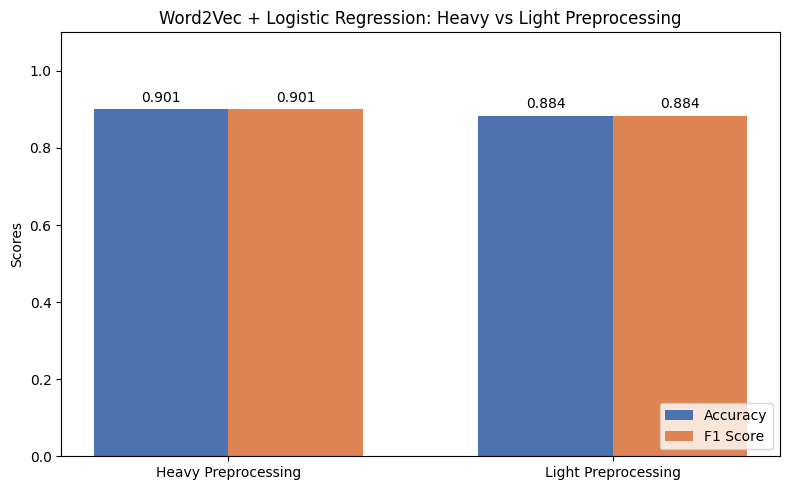

In [61]:
metrics_w2v = {
    'Heavy Preprocessing': {'Accuracy': acc_val_w2v_heavy, 'F1 Score': f1_val_w2v_heavy},
    'Light Preprocessing': {'Accuracy': acc_val_w2v_light, 'F1 Score': f1_val_w2v_light}
}

labels = list(metrics_w2v.keys())
accuracy_vals = [metrics_w2v[label]['Accuracy'] for label in labels]
f1_vals = [metrics_w2v[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores')
ax.set_title('Word2Vec + Logistic Regression: Heavy vs Light Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

Comparing Heavy and Light Data Preprocessing on Logistic Regression using GloVe

In [62]:
def get_glove_document_vector(tokens, glove_dict, vector_size=100):
    valid_words = [word for word in tokens if word in glove_dict]
    if len(valid_words) == 0:
        return np.zeros(vector_size)
    word_vectors = np.array([glove_dict[word] for word in valid_words])
    return np.mean(word_vectors, axis=0)

In [63]:
X_train_glove_heavy = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in train_tokens_glove_heavy])
X_val_glove_heavy = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in val_tokens_glove_heavy])
X_test_glove_heavy = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in test_tokens_glove_heavy])

X_train_glove_light = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in train_tokens_glove_light])
X_val_glove_light = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in val_tokens_glove_light])
X_test_glove_light = np.array([get_glove_document_vector(t, glove_dictionary, 100) for t in test_tokens_glove_light])

In [64]:
lr_model_glove_heavy = LogisticRegression(max_iter=1000, random_state=42)
lr_model_glove_heavy.fit(X_train_glove_heavy, y_train)

y_pred_val_glove_heavy = lr_model_glove_heavy.predict(X_val_glove_heavy)
acc_val_glove_heavy = accuracy_score(y_val, y_pred_val_glove_heavy)
f1_val_glove_heavy = f1_score(y_val, y_pred_val_glove_heavy, average='weighted')

print(f"Accuracy: {acc_val_glove_heavy:.4f} | F1 Score: {f1_val_glove_heavy:.4f}")

Accuracy: 0.8818 | F1 Score: 0.8819


In [65]:
lr_model_glove_light = LogisticRegression(max_iter=1000, random_state=42)
lr_model_glove_light.fit(X_train_glove_light, y_train)

y_pred_val_glove_light = lr_model_glove_light.predict(X_val_glove_light)
acc_val_glove_light = accuracy_score(y_val, y_pred_val_glove_light)
f1_val_glove_light = f1_score(y_val, y_pred_val_glove_light, average='weighted')

print(f"Accuracy: {acc_val_glove_light:.4f} | F1 Score: {f1_val_glove_light:.4f}")

Accuracy: 0.8840 | F1 Score: 0.8838


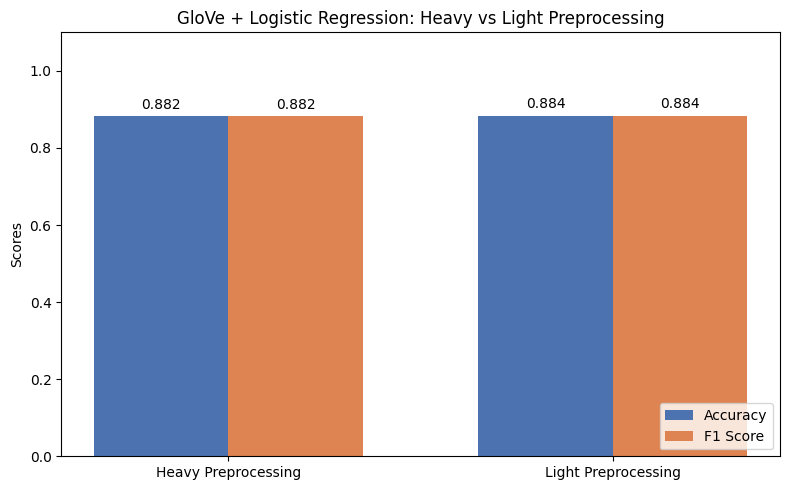

In [66]:
metrics_glove = {
    'Heavy Preprocessing': {'Accuracy': acc_val_glove_heavy, 'F1 Score': f1_val_glove_heavy},
    'Light Preprocessing': {'Accuracy': acc_val_glove_light, 'F1 Score': f1_val_glove_light}
}

labels = list(metrics_glove.keys())
accuracy_vals = [metrics_glove[label]['Accuracy'] for label in labels]
f1_vals = [metrics_glove[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores')
ax.set_title('GloVe + Logistic Regression: Heavy vs Light Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

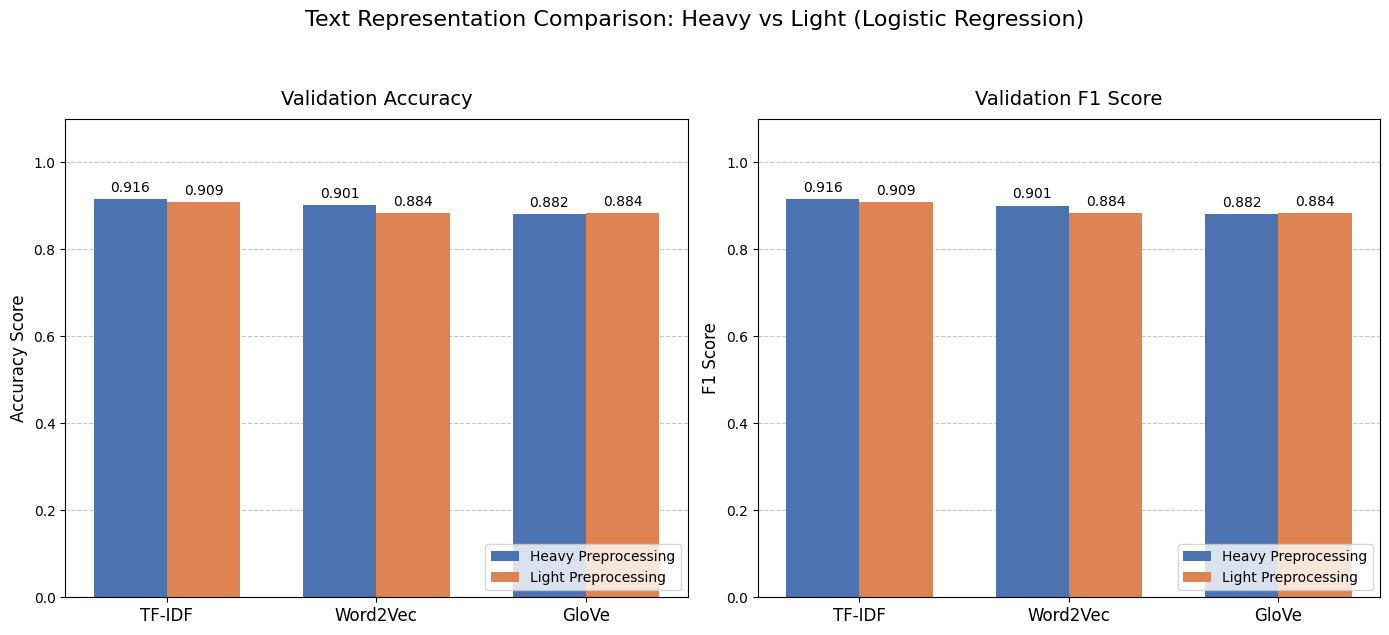

In [67]:
labels = ['TF-IDF', 'Word2Vec', 'GloVe']

acc_heavy_vals = [acc_val_tfidf_heavy, acc_val_w2v_heavy, acc_val_glove_heavy]
acc_light_vals = [acc_val_tfidf_light, acc_val_w2v_light, acc_val_glove_light]

f1_heavy_vals = [f1_val_tfidf_heavy, f1_val_w2v_heavy, f1_val_glove_heavy]
f1_light_vals = [f1_val_tfidf_light, f1_val_w2v_light, f1_val_glove_light]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

rects1_h = ax1.bar(x - width/2, acc_heavy_vals, width, label='Heavy Preprocessing', color='#4C72B0')
rects1_l = ax1.bar(x + width/2, acc_light_vals, width, label='Light Preprocessing', color='#DD8452')

ax1.set_ylabel('Accuracy Score', fontsize=12)
ax1.set_title('Validation Accuracy', fontsize=14, pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_ylim([0, 1.1])
ax1.legend(loc='lower right')
ax1.bar_label(rects1_h, fmt='%.3f', padding=3, fontsize=10)
ax1.bar_label(rects1_l, fmt='%.3f', padding=3, fontsize=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

rects2_h = ax2.bar(x - width/2, f1_heavy_vals, width, label='Heavy Preprocessing', color='#4C72B0')
rects2_l = ax2.bar(x + width/2, f1_light_vals, width, label='Light Preprocessing', color='#DD8452')

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Validation F1 Score', fontsize=14, pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylim([0, 1.1])
ax2.legend(loc='lower right')
ax2.bar_label(rects2_h, fmt='%.3f', padding=3, fontsize=10)
ax2.bar_label(rects2_l, fmt='%.3f', padding=3, fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)

plt.suptitle('Text Representation Comparison: Heavy vs Light (Logistic Regression)', fontsize=16, y=1.05)

fig.tight_layout()
plt.show()

## II. On LSTM

Comparing Heavy and Light Data Preprocessing on LSTM using Word2Vec

In [68]:
lstm_model_w2v_heavy = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=100,
        weights=[embedding_matrix_w2v_heavy],
        trainable=False,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

lstm_model_w2v_heavy.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_w2v_heavy = lstm_model_w2v_heavy.fit(
    train_seq_heavy, y_train_num,
    validation_data=(val_seq_heavy, y_val_num),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7236 - loss: 0.9273 - val_accuracy: 0.8307 - val_loss: 0.5588
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8540 - loss: 0.4848 - val_accuracy: 0.8131 - val_loss: 0.5799
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8705 - loss: 0.4371 - val_accuracy: 0.8889 - val_loss: 0.3382
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8859 - loss: 0.3686 - val_accuracy: 0.8791 - val_loss: 0.3718
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8969 - loss: 0.3316 - val_accuracy: 0.8840 - val_loss: 0.3735
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8972 - loss: 0.3185 - val_accuracy: 0.9043 - val_loss: 0.3081
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9079 - loss: 0.2805 - val_accuracy: 0.9107 - val_loss: 0.2777
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9182 - loss: 0.2458 - val_accu

In [69]:
y_pred_probs_lstm_w2v_heavy = lstm_model_w2v_heavy.predict(val_seq_heavy)
y_pred_lstm_w2v_heavy = np.argmax(y_pred_probs_lstm_w2v_heavy, axis=1)

acc_lstm_w2v_heavy = accuracy_score(y_val_num, y_pred_lstm_w2v_heavy)
f1_lstm_w2v_heavy = f1_score(y_val_num, y_pred_lstm_w2v_heavy, average='weighted')

print(f"\nWord2Vec (Heavy) Validation - Accuracy: {acc_lstm_w2v_heavy:.4f} | F1 Score: {f1_lstm_w2v_heavy:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Word2Vec (Heavy) Validation - Accuracy: 0.9148 | F1 Score: 0.9152


In [70]:
lstm_model_w2v_light = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=100,
        weights=[embedding_matrix_w2v_light],
        trainable=False,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

lstm_model_w2v_light.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_w2v_light = lstm_model_w2v_light.fit(
    train_seq_light, y_train_num,
    validation_data=(val_seq_light, y_val_num),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5366 - loss: 1.3963 - val_accuracy: 0.5293 - val_loss: 1.3995
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5868 - loss: 1.2451 - val_accuracy: 0.6592 - val_loss: 1.0297
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6929 - loss: 0.8997 - val_accuracy: 0.7605 - val_loss: 0.7642
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6854 - loss: 0.9757 - val_accuracy: 0.7264 - val_loss: 0.7640
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6443 - loss: 1.1464 - val_accuracy: 0.7477 - val_loss: 0.8259
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7669 - loss: 0.7723 - val_accuracy: 0.7868 - val_loss: 0.6527
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8063 - loss: 0.6280 - val_accuracy: 0.8326 - val_loss: 0.5672
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8164 - loss: 0.6174 - val_accu

In [71]:
y_pred_probs_lstm_w2v_light = lstm_model_w2v_light.predict(val_seq_light)
y_pred_lstm_w2v_light = np.argmax(y_pred_probs_lstm_w2v_light, axis=1)

acc_lstm_w2v_light = accuracy_score(y_val_num, y_pred_lstm_w2v_light)
f1_lstm_w2v_light = f1_score(y_val_num, y_pred_lstm_w2v_light, average='weighted')

print(f"\nWord2Vec (light) Validation - Accuracy: {acc_lstm_w2v_light:.4f} | F1 Score: {f1_lstm_w2v_light:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Word2Vec (light) Validation - Accuracy: 0.8660 | F1 Score: 0.8674


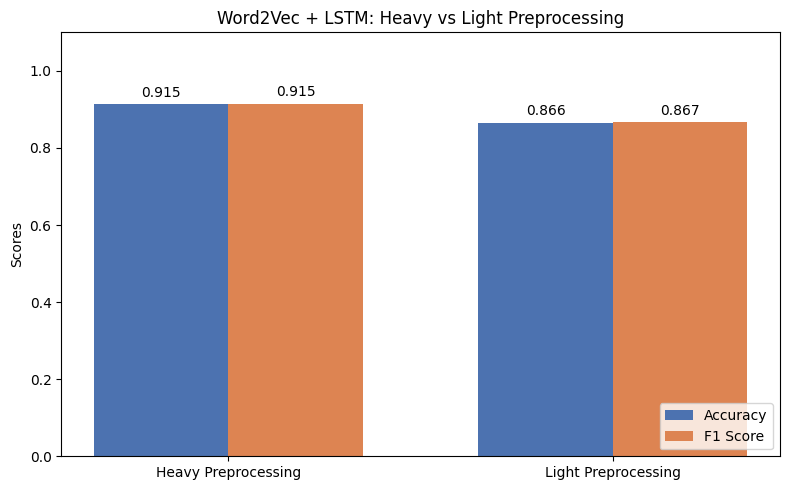

In [72]:
metrics_lstm_w2v = {
    'Heavy Preprocessing': {'Accuracy': acc_lstm_w2v_heavy, 'F1 Score': f1_lstm_w2v_heavy},
    'Light Preprocessing': {'Accuracy': acc_lstm_w2v_light, 'F1 Score': f1_lstm_w2v_light}
}

labels = list(metrics_lstm_w2v.keys())
accuracy_vals = [metrics_lstm_w2v[label]['Accuracy'] for label in labels]
f1_vals = [metrics_lstm_w2v[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores')
ax.set_title('Word2Vec + LSTM: Heavy vs Light Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

Comparing Heavy and Light Data Preprocessing on LSTM using GloVe

In [73]:
lstm_model_glove_heavy = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=100,
        weights=[embedding_matrix_glove_heavy],
        trainable=False,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

lstm_model_glove_heavy.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_glove_heavy = lstm_model_glove_heavy.fit(
    train_seq_heavy, y_train_num,
    validation_data=(val_seq_heavy, y_val_num),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6745 - loss: 1.0220 - val_accuracy: 0.8390 - val_loss: 0.5233
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8505 - loss: 0.4975 - val_accuracy: 0.8589 - val_loss: 0.4350
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8582 - loss: 0.4555 - val_accuracy: 0.8791 - val_loss: 0.3909
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8914 - loss: 0.3523 - val_accuracy: 0.8896 - val_loss: 0.3495
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9048 - loss: 0.3014 - val_accuracy: 0.8953 - val_loss: 0.3095
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9151 - loss: 0.2570 - val_accuracy: 0.9039 - val_loss: 0.2990
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9222 - loss: 0.2336 - val_accuracy: 0.8953 - val_loss: 0.3184
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9329 - loss: 0.2144 - val_accu

In [74]:
y_pred_probs_lstm_glove_heavy = lstm_model_glove_heavy.predict(val_seq_heavy)
y_pred_lstm_glove_heavy = np.argmax(y_pred_probs_lstm_glove_heavy, axis=1)

acc_lstm_glove_heavy = accuracy_score(y_val_num, y_pred_lstm_glove_heavy)
f1_lstm_glove_heavy = f1_score(y_val_num, y_pred_lstm_glove_heavy, average='weighted')

print(f"\nGloVe (Heavy) Validation - Accuracy: {acc_lstm_glove_heavy:.4f} | F1 Score: {f1_lstm_glove_heavy:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

GloVe (Heavy) Validation - Accuracy: 0.9129 | F1 Score: 0.9131


In [75]:
lstm_model_glove_light = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=100,
        weights=[embedding_matrix_glove_light],  # Using GloVe Light Matrix
        trainable=False,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

lstm_model_glove_light.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_glove_light = lstm_model_glove_light.fit(
    train_seq_light, y_train_num,
    validation_data=(val_seq_light, y_val_num),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5118 - loss: 1.4229 - val_accuracy: 0.7447 - val_loss: 0.7961
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7527 - loss: 0.7610 - val_accuracy: 0.8318 - val_loss: 0.5576
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8288 - loss: 0.5552 - val_accuracy: 0.8592 - val_loss: 0.4380
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8706 - loss: 0.4290 - val_accuracy: 0.8724 - val_loss: 0.3977
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8894 - loss: 0.3594 - val_accuracy: 0.8915 - val_loss: 0.3599
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8991 - loss: 0.3252 - val_accuracy: 0.8986 - val_loss: 0.3182
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9098 - loss: 0.2845 - val_accuracy: 0.8964 - val_loss: 0.3287
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9174 - loss: 0.2584 - val_accu

In [76]:
y_pred_probs_lstm_glove_light = lstm_model_glove_light.predict(val_seq_light)
y_pred_lstm_glove_light = np.argmax(y_pred_probs_lstm_glove_light, axis=1)

acc_lstm_glove_light = accuracy_score(y_val_num, y_pred_lstm_glove_light)
f1_lstm_glove_light = f1_score(y_val_num, y_pred_lstm_glove_light, average='weighted')

print(f"\nGloVe (Light) Validation - Accuracy: {acc_lstm_glove_light:.4f} | F1 Score: {f1_lstm_glove_light:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

GloVe (Light) Validation - Accuracy: 0.8960 | F1 Score: 0.8966


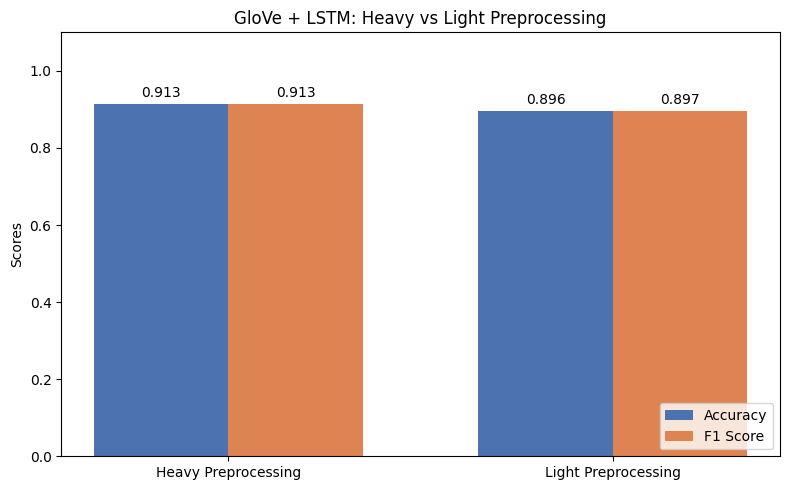

In [77]:
metrics_lstm_glove = {
    'Heavy Preprocessing': {'Accuracy': acc_lstm_glove_heavy, 'F1 Score': f1_lstm_glove_heavy},
    'Light Preprocessing': {'Accuracy': acc_lstm_glove_light, 'F1 Score': f1_lstm_glove_light}
}

labels = list(metrics_lstm_glove.keys())
accuracy_vals = [metrics_lstm_glove[label]['Accuracy'] for label in labels]
f1_vals = [metrics_lstm_glove[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores')
ax.set_title('GloVe + LSTM: Heavy vs Light Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

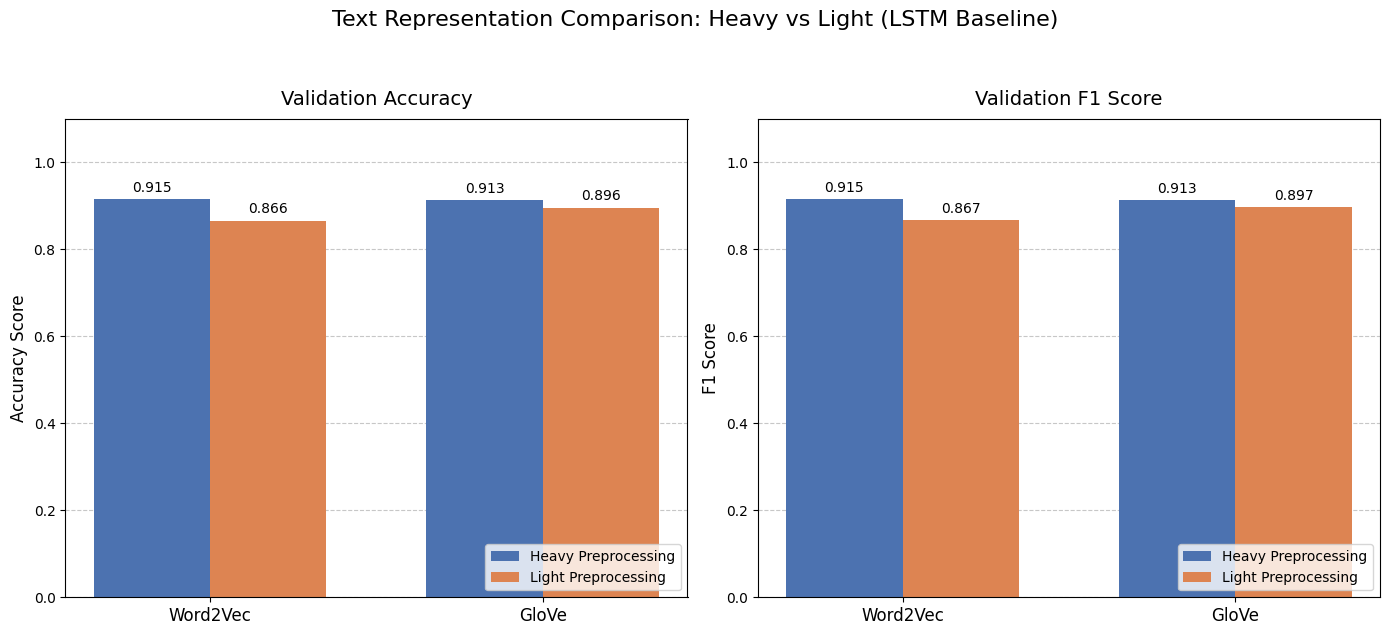

In [78]:
labels = ['Word2Vec', 'GloVe']

acc_heavy_vals_lstm = [acc_lstm_w2v_heavy, acc_lstm_glove_heavy]
acc_light_vals_lstm = [acc_lstm_w2v_light, acc_lstm_glove_light]

f1_heavy_vals_lstm = [f1_lstm_w2v_heavy, f1_lstm_glove_heavy]
f1_light_vals_lstm = [f1_lstm_w2v_light, f1_lstm_glove_light]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

rects1_h = ax1.bar(x - width/2, acc_heavy_vals_lstm, width, label='Heavy Preprocessing', color='#4C72B0')
rects1_l = ax1.bar(x + width/2, acc_light_vals_lstm, width, label='Light Preprocessing', color='#DD8452')

ax1.set_ylabel('Accuracy Score', fontsize=12)
ax1.set_title('Validation Accuracy', fontsize=14, pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_ylim([0, 1.1])
ax1.legend(loc='lower right')
ax1.bar_label(rects1_h, fmt='%.3f', padding=3, fontsize=10)
ax1.bar_label(rects1_l, fmt='%.3f', padding=3, fontsize=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

rects2_h = ax2.bar(x - width/2, f1_heavy_vals_lstm, width, label='Heavy Preprocessing', color='#4C72B0')
rects2_l = ax2.bar(x + width/2, f1_light_vals_lstm, width, label='Light Preprocessing', color='#DD8452')

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Validation F1 Score', fontsize=14, pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylim([0, 1.1])
ax2.legend(loc='lower right')
ax2.bar_label(rects2_h, fmt='%.3f', padding=3, fontsize=10)
ax2.bar_label(rects2_l, fmt='%.3f', padding=3, fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)

plt.suptitle('Text Representation Comparison: Heavy vs Light (LSTM Baseline)', fontsize=16, y=1.05)

fig.tight_layout()
plt.show()

## III. On BERT Base

Comparing Heavy and Light Data Preprocessing on BERT Base using BERT's Tokenizer

In [79]:
model_heavy = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=10
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./bert_heavy",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=50,
    eval_strategy="epoch",
)

trainer_heavy = Trainer(
    model=model_heavy,
    args=training_args,
    train_dataset=train_dataset_heavy,
    eval_dataset=val_dataset_heavy,
    compute_metrics=compute_metrics,
)

trainer_heavy.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.297596,0.273595,0.923048,0.922917
2,0.158669,0.241578,0.939940,0.940134
3,0.052640,0.243915,0.947447,0.947591


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2331, training_loss=0.21164468903748174, metrics={'train_runtime': 1262.114, 'train_samples_per_second': 29.55, 'train_steps_per_second': 1.847, 'total_flos': 2875105891324800.0, 'train_loss': 0.21164468903748174, 'epoch': 3.0})

In [80]:
model_light = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=10
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./bert_light",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=50,
    eval_strategy="epoch",
)

trainer_light = Trainer(
    model=model_light,
    args=training_args,
    train_dataset=train_dataset_light,
    eval_dataset=val_dataset_light,
    compute_metrics=compute_metrics,
)

trainer_light.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263830,0.239612,0.925300,0.925694
2,0.149021,0.264425,0.932432,0.932719
3,0.032611,0.224196,0.947823,0.947892


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2331, training_loss=0.18958657292120962, metrics={'train_runtime': 1359.3714, 'train_samples_per_second': 27.436, 'train_steps_per_second': 1.715, 'total_flos': 2875105891324800.0, 'train_loss': 0.18958657292120962, 'epoch': 3.0})

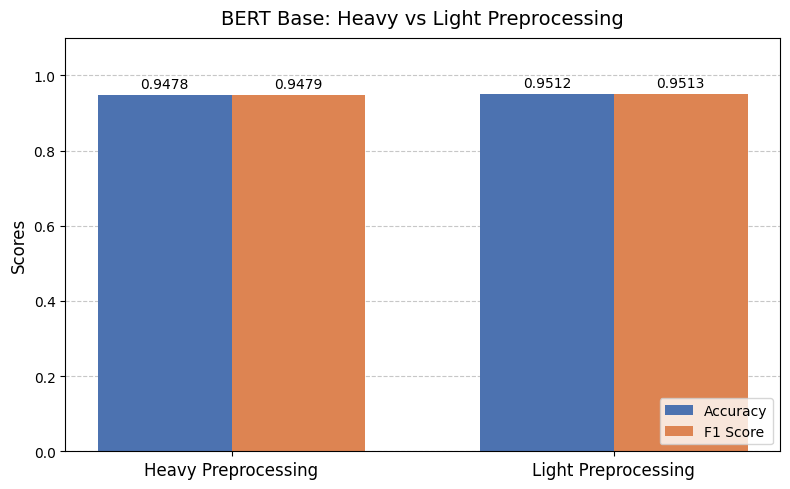

In [81]:
metrics_bert = {
    'Heavy Preprocessing': {'Accuracy': 0.9478, 'F1 Score': 0.9479},
    'Light Preprocessing': {'Accuracy': 0.9512, 'F1 Score': 0.9513}
}

labels = list(metrics_bert.keys())
accuracy_vals = [metrics_bert[label]['Accuracy'] for label in labels]
f1_vals = [metrics_bert[label]['F1 Score'] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('BERT Base: Heavy vs Light Preprocessing', fontsize=14, pad=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.4f', padding=3, fontsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

# 11. Model Development & Hyperparameter Tuning

## I. Random Forest

Configuration 1: Standard Baseline

In [82]:
rf_config1 = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
rf_config1.fit(X_train_tfidf_heavy, y_train_num)

y_pred_rf1 = rf_config1.predict(X_val_tfidf_heavy)
acc_rf1 = accuracy_score(y_val_num, y_pred_rf1)
f1_rf1 = f1_score(y_val_num, y_pred_rf1, average='weighted')

Configuration 2: Large, Restricted Forest

In [83]:
rf_config2 = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1)
rf_config2.fit(X_train_tfidf_heavy, y_train_num)

y_pred_rf2 = rf_config2.predict(X_val_tfidf_heavy)
acc_rf2 = accuracy_score(y_val_num, y_pred_rf2)
f1_rf2 = f1_score(y_val_num, y_pred_rf2, average='weighted')

Configuration 3: Fast, Pruned Forest

In [84]:
rf_config3 = RandomForestClassifier(n_estimators=50, min_samples_split=10, random_state=42, n_jobs=-1)
rf_config3.fit(X_train_tfidf_heavy, y_train_num)

y_pred_rf3 = rf_config3.predict(X_val_tfidf_heavy)
acc_rf3 = accuracy_score(y_val_num, y_pred_rf3)
f1_rf3 = f1_score(y_val_num, y_pred_rf3, average='weighted')

Comparison

In [85]:
rf_results_df = pd.DataFrame({
    'Model': ['Random Forest'] * 3,
    'Config': [
        "n_estimators=100, max_depth=None",
        "n_estimators=200, max_depth=50",
        "n_estimators=50, min_samples_split=10"
    ],
    'Accuracy': [acc_rf1, acc_rf2, acc_rf3],
    'F1 Score': [f1_rf1, f1_rf2, f1_rf3]
})

display(rf_results_df)

,Model,Config,Accuracy,F1 Score
0,Random Forest,"n_estimators=100, max_depth=None",0.884384,0.884208
1,Random Forest,"n_estimators=200, max_depth=50",0.883634,0.883353
2,Random Forest,"n_estimators=50, min_samples_split=10",0.871622,0.871098


## II. Logistic Regression

Configuration 1: Standard Baseline

In [86]:
lr_config1 = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_config1.fit(X_train_tfidf_heavy, y_train_num)

y_pred1 = lr_config1.predict(X_val_tfidf_heavy)
acc1 = accuracy_score(y_val_num, y_pred1)
f1_1 = f1_score(y_val_num, y_pred1, average='weighted')

Configuration 2: High Regularization (L1 / Lasso)

In [87]:
lr_config2 = LogisticRegression(C=0.1, penalty='l1', solver='saga', max_iter=1000, random_state=42)
lr_config2.fit(X_train_tfidf_heavy, y_train_num)

y_pred2 = lr_config2.predict(X_val_tfidf_heavy)
acc2 = accuracy_score(y_val_num, y_pred2)
f1_2 = f1_score(y_val_num, y_pred2, average='weighted')

Configuration 3: Low Regularization

In [88]:
lr_config3 = LogisticRegression(C=10.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_config3.fit(X_train_tfidf_heavy, y_train_num)

y_pred3 = lr_config3.predict(X_val_tfidf_heavy)
acc3 = accuracy_score(y_val_num, y_pred3)
f1_3 = f1_score(y_val_num, y_pred3, average='weighted')

Comparison

In [89]:
lr_results_df = pd.DataFrame({
    'Model': ['Logistic Regression'] * 3,
    'Config': [
        "C=1.0, penalty='l2', solver='lbfgs'",
        "C=0.1, penalty='l1', solver='saga'",
        "C=10.0, penalty='l2', solver='lbfgs'"
    ],
    'Accuracy': [acc1, acc2, acc3],
    'F1 Score': [f1_1, f1_2, f1_3]
})

display(lr_results_df)

,Model,Config,Accuracy,F1 Score
0,Logistic Regression,"C=1.0, penalty='l2', solver='lbfgs'",0.915916,0.916101
1,Logistic Regression,"C=0.1, penalty='l1', solver='saga'",0.814565,0.816623
2,Logistic Regression,"C=10.0, penalty='l2', solver='lbfgs'",0.916291,0.916486


## III. Naive Bayes

Configuration 1: Standard Baseline

In [90]:
nb_config1 = MultinomialNB(alpha=1.0)
nb_config1.fit(X_train_tfidf_heavy, y_train_num)

y_pred_nb1 = nb_config1.predict(X_val_tfidf_heavy)
acc_nb1 = accuracy_score(y_val_num, y_pred_nb1)
f1_nb1 = f1_score(y_val_num, y_pred_nb1, average='weighted')

Configuration 2: Low Smoothing

In [91]:
nb_config2 = MultinomialNB(alpha=0.1)
nb_config2.fit(X_train_tfidf_heavy, y_train_num)

y_pred_nb2 = nb_config2.predict(X_val_tfidf_heavy)
acc_nb2 = accuracy_score(y_val_num, y_pred_nb2)
f1_nb2 = f1_score(y_val_num, y_pred_nb2, average='weighted')

Configuration 1: High Smoothing

In [92]:
nb_config3 = MultinomialNB(alpha=10.0)
nb_config3.fit(X_train_tfidf_heavy, y_train_num)

y_pred_nb3 = nb_config3.predict(X_val_tfidf_heavy)
acc_nb3 = accuracy_score(y_val_num, y_pred_nb3)
f1_nb3 = f1_score(y_val_num, y_pred_nb3, average='weighted')

Comparison

In [93]:
nb_results_df = pd.DataFrame({
    'Model': ['Naive Bayes'] * 3,
    'Config': [
        "alpha=1.0",
        "alpha=0.1",
        "alpha=10.0"
    ],
    'Accuracy': [acc_nb1, acc_nb2, acc_nb3],
    'F1 Score': [f1_nb1, f1_nb2, f1_nb3]
})

display(nb_results_df)

,Model,Config,Accuracy,F1 Score
0,Naive Bayes,alpha=1.0,0.890390,0.889943
1,Naive Bayes,alpha=0.1,0.885135,0.884722
2,Naive Bayes,alpha=10.0,0.886637,0.885649


## IV. SimpleRNN

Configuration 1: Standard Baseline

In [94]:
rnn_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

rnn_config1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_rnn1 = rnn_config1.predict(val_seq_heavy)
y_pred_rnn1 = np.argmax(predictions_rnn1, axis=1)
acc_rnn1 = accuracy_score(y_val_num, y_pred_rnn1)
f1_rnn1 = f1_score(y_val_num, y_pred_rnn1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.4199 - loss: 1.6051 - val_accuracy: 0.4797 - val_loss: 1.5072
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4932 - loss: 1.4782 - val_accuracy: 0.5124 - val_loss: 1.4093
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3695 - loss: 1.7892 - val_accuracy: 0.3164 - val_loss: 1.9940
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3431 - loss: 1.8438 - val_accuracy: 0.4298 - val_loss: 1.6176
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4444 - loss: 1.5694 - val_accuracy: 0.4906 - val_loss: 1.4673
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


Configuration 2: High Capacity

In [95]:
rnn_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    SimpleRNN(128),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

rnn_config2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_rnn2 = rnn_config2.predict(val_seq_heavy)
y_pred_rnn2 = np.argmax(predictions_rnn2, axis=1)
acc_rnn2 = accuracy_score(y_val_num, y_pred_rnn2)
f1_rnn2 = f1_score(y_val_num, y_pred_rnn2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.4487 - loss: 1.5509 - val_accuracy: 0.5646 - val_loss: 1.3185
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4716 - loss: 1.5293 - val_accuracy: 0.4842 - val_loss: 1.4501
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4777 - loss: 1.4567 - val_accuracy: 0.6032 - val_loss: 1.1195
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4750 - loss: 1.5321 - val_accuracy: 0.4456 - val_loss: 1.5209
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4276 - loss: 1.6064 - val_accuracy: 0.5619 - val_loss: 1.2525
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


Configuration 3: High Regularization / Lightweight

In [96]:
rnn_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    SimpleRNN(32, dropout=0.5),
    Dense(10, activation='softmax')
])

rnn_config3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_rnn3 = rnn_config3.predict(val_seq_heavy)
y_pred_rnn3 = np.argmax(predictions_rnn3, axis=1)
acc_rnn3 = accuracy_score(y_val_num, y_pred_rnn3)
f1_rnn3 = f1_score(y_val_num, y_pred_rnn3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.2124 - loss: 2.1615 - val_accuracy: 0.3461 - val_loss: 1.7590
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3678 - loss: 1.7435 - val_accuracy: 0.4977 - val_loss: 1.3797
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4165 - loss: 1.6249 - val_accuracy: 0.5522 - val_loss: 1.2952
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4599 - loss: 1.5318 - val_accuracy: 0.5661 - val_loss: 1.2669
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4355 - loss: 1.6059 - val_accuracy: 0.5139 - val_loss: 1.4395
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


Comparison

In [97]:
rnn_results_df = pd.DataFrame({
    'Model': ['SimpleRNN'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_rnn1, acc_rnn2, acc_rnn3],
    'F1 Score': [f1_rnn1, f1_rnn2, f1_rnn3]
})

display(rnn_results_df)

,Model,Config,Accuracy,F1 Score
0,SimpleRNN,"units=64, dropout=0.2",0.490616,0.475997
1,SimpleRNN,"units=128, dropout=0.3",0.561937,0.548433
2,SimpleRNN,"units=32, dropout=0.5",0.513889,0.508098


## V. GRU

Configuration 1: Standard Baseline

In [98]:
gru_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    GRU(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

gru_config1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_gru1 = gru_config1.predict(val_seq_heavy)
y_pred_gru1 = np.argmax(predictions_gru1, axis=1)
acc_gru1 = accuracy_score(y_val_num, y_pred_gru1)
f1_gru1 = f1_score(y_val_num, y_pred_gru1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6614 - loss: 1.0016 - val_accuracy: 0.8660 - val_loss: 0.4284
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8803 - loss: 0.3716 - val_accuracy: 0.8956 - val_loss: 0.3237
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9084 - loss: 0.2794 - val_accuracy: 0.9080 - val_loss: 0.2571
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9220 - loss: 0.2356 - val_accuracy: 0.9054 - val_loss: 0.2691
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9310 - loss: 0.2046 - val_accuracy: 0.9167 - val_loss: 0.2330
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Configuration 2: High Capacity

In [99]:
gru_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    GRU(128, dropout=0.3),
    Dense(10, activation='softmax')
])

gru_config2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_gru2 = gru_config2.predict(val_seq_heavy)
y_pred_gru2 = np.argmax(predictions_gru2, axis=1)
acc_gru2 = accuracy_score(y_val_num, y_pred_gru2)
f1_gru2 = f1_score(y_val_num, y_pred_gru2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6699 - loss: 0.9622 - val_accuracy: 0.8791 - val_loss: 0.3746
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8658 - loss: 0.3920 - val_accuracy: 0.9069 - val_loss: 0.2852
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8893 - loss: 0.3222 - val_accuracy: 0.9118 - val_loss: 0.2386
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9019 - loss: 0.2747 - val_accuracy: 0.9155 - val_loss: 0.2352
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9060 - loss: 0.2625 - val_accuracy: 0.9200 - val_loss: 0.2232
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


Configuration 3: High Regularization / Lightweight

In [100]:
gru_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    GRU(32, dropout=0.5),
    Dense(10, activation='softmax')
])

gru_config3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_gru3 = gru_config3.predict(val_seq_heavy)
y_pred_gru3 = np.argmax(predictions_gru3, axis=1)
acc_gru3 = accuracy_score(y_val_num, y_pred_gru3)
f1_gru3 = f1_score(y_val_num, y_pred_gru3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4022 - loss: 1.7201 - val_accuracy: 0.7406 - val_loss: 0.8237
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7262 - loss: 0.8247 - val_accuracy: 0.8412 - val_loss: 0.4972
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7928 - loss: 0.6136 - val_accuracy: 0.8675 - val_loss: 0.4099
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8226 - loss: 0.5267 - val_accuracy: 0.8836 - val_loss: 0.3453
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8389 - loss: 0.4837 - val_accuracy: 0.8923 - val_loss: 0.3223
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Comparison

In [101]:
gru_results_df = pd.DataFrame({
    'Model': ['GRU'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_gru1, acc_gru2, acc_gru3],
    'F1 Score': [f1_gru1, f1_gru2, f1_gru3]
})

display(gru_results_df)

,Model,Config,Accuracy,F1 Score
0,GRU,"units=64, dropout=0.2",0.916667,0.917021
1,GRU,"units=128, dropout=0.3",0.920045,0.919996
2,GRU,"units=32, dropout=0.5",0.892267,0.892052


## VI. LSTM

Configuration 1: Standard Baseline

In [102]:
lstm_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

lstm_config1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_lstm1 = lstm_config1.predict(val_seq_heavy)
y_pred_lstm1 = np.argmax(predictions_lstm1, axis=1)
acc_lstm1 = accuracy_score(y_val_num, y_pred_lstm1)
f1_lstm1 = f1_score(y_val_num, y_pred_lstm1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7241 - loss: 0.8930 - val_accuracy: 0.8514 - val_loss: 0.5031
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8521 - loss: 0.4986 - val_accuracy: 0.8720 - val_loss: 0.4023
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8834 - loss: 0.3751 - val_accuracy: 0.8923 - val_loss: 0.3544
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9017 - loss: 0.3131 - val_accuracy: 0.8656 - val_loss: 0.3681
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9097 - loss: 0.2763 - val_accuracy: 0.8975 - val_loss: 0.3075
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Configuration 2: High Capacity

In [103]:
lstm_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    LSTM(128, dropout=0.3),
    Dense(10, activation='softmax')
])

lstm_config2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_lstm2 = lstm_config2.predict(val_seq_heavy)
y_pred_lstm2 = np.argmax(predictions_lstm2, axis=1)
acc_lstm2 = accuracy_score(y_val_num, y_pred_lstm2)
f1_lstm2 = f1_score(y_val_num, y_pred_lstm2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6760 - loss: 0.9606 - val_accuracy: 0.8202 - val_loss: 0.5747
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8130 - loss: 0.5847 - val_accuracy: 0.8221 - val_loss: 0.6656
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8477 - loss: 0.4758 - val_accuracy: 0.8926 - val_loss: 0.3278
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8687 - loss: 0.3957 - val_accuracy: 0.8938 - val_loss: 0.3195
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8833 - loss: 0.3575 - val_accuracy: 0.9065 - val_loss: 0.2657
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


Configuration 3: High Regularization / Lightweight

In [104]:
lstm_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    LSTM(32, dropout=0.5),
    Dense(10, activation='softmax')
])

lstm_config3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_lstm3 = lstm_config3.predict(val_seq_heavy)
y_pred_lstm3 = np.argmax(predictions_lstm3, axis=1)
acc_lstm3 = accuracy_score(y_val_num, y_pred_lstm3)
f1_lstm3 = f1_score(y_val_num, y_pred_lstm3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4623 - loss: 1.5609 - val_accuracy: 0.7631 - val_loss: 0.7440
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7090 - loss: 0.8703 - val_accuracy: 0.8570 - val_loss: 0.4954
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7720 - loss: 0.6824 - val_accuracy: 0.8716 - val_loss: 0.4174
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7997 - loss: 0.5919 - val_accuracy: 0.8784 - val_loss: 0.3737
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8228 - loss: 0.5356 - val_accuracy: 0.8863 - val_loss: 0.3455
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Comparison

In [105]:
lstm_results_df = pd.DataFrame({
    'Model': ['LSTM'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_lstm1, acc_lstm2, acc_lstm3],
    'F1 Score': [f1_lstm1, f1_lstm2, f1_lstm3]
})

display(lstm_results_df)

,Model,Config,Accuracy,F1 Score
0,LSTM,"units=64, dropout=0.2",0.897523,0.897265
1,LSTM,"units=128, dropout=0.3",0.906532,0.906291
2,LSTM,"units=32, dropout=0.5",0.886261,0.885864


## VII. Bidirectional SimpleRNN

Configuration 1: Standard Baseline

In [106]:
birnn_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(SimpleRNN(64)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

birnn_config1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
birnn_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_birnn1 = birnn_config1.predict(val_seq_heavy)
y_pred_birnn1 = np.argmax(predictions_birnn1, axis=1)
acc_birnn1 = accuracy_score(y_val_num, y_pred_birnn1)
f1_birnn1 = f1_score(y_val_num, y_pred_birnn1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.6918 - loss: 0.9193 - val_accuracy: 0.8285 - val_loss: 0.5236
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8393 - loss: 0.4833 - val_accuracy: 0.8367 - val_loss: 0.4863
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8598 - loss: 0.4306 - val_accuracy: 0.8581 - val_loss: 0.4171
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8756 - loss: 0.3731 - val_accuracy: 0.8664 - val_loss: 0.4036
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8846 - loss: 0.3428 - val_accuracy: 0.8773 - val_loss: 0.3851
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


Configuration 2: High Capacity

In [107]:
birnn_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(SimpleRNN(128)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

birnn_config2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
birnn_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_birnn2 = birnn_config2.predict(val_seq_heavy)
y_pred_birnn2 = np.argmax(predictions_birnn2, axis=1)
acc_birnn2 = accuracy_score(y_val_num, y_pred_birnn2)
f1_birnn2 = f1_score(y_val_num, y_pred_birnn2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7369 - loss: 0.7785 - val_accuracy: 0.8337 - val_loss: 0.4948
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8569 - loss: 0.4272 - val_accuracy: 0.8686 - val_loss: 0.3955
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8764 - loss: 0.3657 - val_accuracy: 0.8577 - val_loss: 0.4304
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8892 - loss: 0.3211 - val_accuracy: 0.8814 - val_loss: 0.3630
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8984 - loss: 0.2901 - val_accuracy: 0.8615 - val_loss: 0.4305
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


Configuration 3: High Regularization / Lightweight




In [108]:
birnn_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

birnn_config3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
birnn_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_birnn3 = birnn_config3.predict(val_seq_heavy)
y_pred_birnn3 = np.argmax(predictions_birnn3, axis=1)
acc_birnn3 = accuracy_score(y_val_num, y_pred_birnn3)
f1_birnn3 = f1_score(y_val_num, y_pred_birnn3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.5030 - loss: 1.4589 - val_accuracy: 0.7958 - val_loss: 0.6750
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.7443 - loss: 0.7733 - val_accuracy: 0.8187 - val_loss: 0.5648
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7872 - loss: 0.6553 - val_accuracy: 0.8401 - val_loss: 0.5019
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8130 - loss: 0.5898 - val_accuracy: 0.8709 - val_loss: 0.4158
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8369 - loss: 0.5327 - val_accuracy: 0.8690 - val_loss: 0.4275
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


Comparison

In [109]:
birnn_results_df = pd.DataFrame({
    'Model': ['Bidirectional SimpleRNN'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_birnn1, acc_birnn2, acc_birnn3],
    'F1 Score': [f1_birnn1, f1_birnn2, f1_birnn3]
})

display(birnn_results_df)

,Model,Config,Accuracy,F1 Score
0,Bidirectional SimpleRNN,"units=64, dropout=0.2",0.877252,0.876974
1,Bidirectional SimpleRNN,"units=128, dropout=0.3",0.861486,0.861451
2,Bidirectional SimpleRNN,"units=32, dropout=0.5",0.868994,0.868840


## VIII. Bidirectional GRU

Configuration 1: Standard Baseline

In [110]:
bigru_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(GRU(64)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

bigru_config1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bigru_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bigru1 = bigru_config1.predict(val_seq_heavy)
y_pred_bigru1 = np.argmax(predictions_bigru1, axis=1)
acc_bigru1 = accuracy_score(y_val_num, y_pred_bigru1)
f1_bigru1 = f1_score(y_val_num, y_pred_bigru1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7950 - loss: 0.6449 - val_accuracy: 0.8938 - val_loss: 0.3091
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9065 - loss: 0.2666 - val_accuracy: 0.9167 - val_loss: 0.2493
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9201 - loss: 0.2186 - val_accuracy: 0.9103 - val_loss: 0.2456
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9322 - loss: 0.1862 - val_accuracy: 0.9140 - val_loss: 0.2413
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9410 - loss: 0.1634 - val_accuracy: 0.9167 - val_loss: 0.2304
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Configuration 2: High Capacity

In [111]:
bigru_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(GRU(128)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

bigru_config2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bigru_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bigru2 = bigru_config2.predict(val_seq_heavy)
y_pred_bigru2 = np.argmax(predictions_bigru2, axis=1)
acc_bigru2 = accuracy_score(y_val_num, y_pred_bigru2)
f1_bigru2 = f1_score(y_val_num, y_pred_bigru2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8222 - loss: 0.5512 - val_accuracy: 0.9024 - val_loss: 0.2913
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9131 - loss: 0.2493 - val_accuracy: 0.9069 - val_loss: 0.2710
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9265 - loss: 0.2091 - val_accuracy: 0.9167 - val_loss: 0.2366
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9386 - loss: 0.1736 - val_accuracy: 0.9219 - val_loss: 0.2195
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9492 - loss: 0.1434 - val_accuracy: 0.9204 - val_loss: 0.2332
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Configuration 3: High Regularization / Lightweight




In [112]:
bigru_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(GRU(32)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

bigru_config3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bigru_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bigru3 = bigru_config3.predict(val_seq_heavy)
y_pred_bigru3 = np.argmax(predictions_bigru3, axis=1)
acc_bigru3 = accuracy_score(y_val_num, y_pred_bigru3)
f1_bigru3 = f1_score(y_val_num, y_pred_bigru3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6727 - loss: 1.0264 - val_accuracy: 0.8758 - val_loss: 0.3957
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8729 - loss: 0.3888 - val_accuracy: 0.9050 - val_loss: 0.2738
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9008 - loss: 0.3005 - val_accuracy: 0.9152 - val_loss: 0.2526
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9128 - loss: 0.2641 - val_accuracy: 0.9092 - val_loss: 0.2473
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9185 - loss: 0.2432 - val_accuracy: 0.9167 - val_loss: 0.2269
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Comparison

In [113]:
bigru_results_df = pd.DataFrame({
    'Model': ['Bidirectional GRU'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_bigru1, acc_bigru2, acc_bigru3],
    'F1 Score': [f1_bigru1, f1_bigru2, f1_bigru3]
})

display(bigru_results_df)

,Model,Config,Accuracy,F1 Score
0,Bidirectional GRU,"units=64, dropout=0.2",0.916667,0.917076
1,Bidirectional GRU,"units=128, dropout=0.3",0.920420,0.920475
2,Bidirectional GRU,"units=32, dropout=0.5",0.916667,0.916633


## IX. Bidirectional LSTM

Configuration 1: Standard Baseline

In [114]:
bilstm_config1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

bilstm_config1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bilstm_config1.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bilstm1 = bilstm_config1.predict(val_seq_heavy)
y_pred_bilstm1 = np.argmax(predictions_bilstm1, axis=1)
acc_bilstm1 = accuracy_score(y_val_num, y_pred_bilstm1)
f1_bilstm1 = f1_score(y_val_num, y_pred_bilstm1, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8104 - loss: 0.6154 - val_accuracy: 0.8859 - val_loss: 0.3351
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8951 - loss: 0.3001 - val_accuracy: 0.8934 - val_loss: 0.2977
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9157 - loss: 0.2387 - val_accuracy: 0.9148 - val_loss: 0.2527
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9304 - loss: 0.2038 - val_accuracy: 0.9148 - val_loss: 0.2508
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9382 - loss: 0.1781 - val_accuracy: 0.9137 - val_loss: 0.2490
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Configuration 2: High Capacity

In [115]:
bilstm_config2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

bilstm_config2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bilstm_config2.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bilstm2 = bilstm_config2.predict(val_seq_heavy)
y_pred_bilstm2 = np.argmax(predictions_bilstm2, axis=1)
acc_bilstm2 = accuracy_score(y_val_num, y_pred_bilstm2)
f1_bilstm2 = f1_score(y_val_num, y_pred_bilstm2, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8184 - loss: 0.5417 - val_accuracy: 0.8983 - val_loss: 0.3053
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9024 - loss: 0.2915 - val_accuracy: 0.9092 - val_loss: 0.2610
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9179 - loss: 0.2385 - val_accuracy: 0.9133 - val_loss: 0.2614
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9309 - loss: 0.2014 - val_accuracy: 0.9133 - val_loss: 0.2580
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9376 - loss: 0.1755 - val_accuracy: 0.9208 - val_loss: 0.2441
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


Configuration 3: High Regularization / Lightweight




In [116]:
bilstm_config3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=100, weights=[embedding_matrix_glove_heavy], trainable=False, mask_zero=True),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

bilstm_config3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
bilstm_config3.fit(train_seq_heavy, y_train_num, validation_data=(val_seq_heavy, y_val_num), epochs=5, batch_size=32, verbose=1)

predictions_bilstm3 = bilstm_config3.predict(val_seq_heavy)
y_pred_bilstm3 = np.argmax(predictions_bilstm3, axis=1)
acc_bilstm3 = accuracy_score(y_val_num, y_pred_bilstm3)
f1_bilstm3 = f1_score(y_val_num, y_pred_bilstm3, average='weighted')

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7173 - loss: 0.9042 - val_accuracy: 0.8671 - val_loss: 0.4065
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8670 - loss: 0.4089 - val_accuracy: 0.8926 - val_loss: 0.3233
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8901 - loss: 0.3426 - val_accuracy: 0.9077 - val_loss: 0.2714
Epoch 4/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9044 - loss: 0.2946 - val_accuracy: 0.9152 - val_loss: 0.2504
Epoch 5/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9143 - loss: 0.2577 - val_accuracy: 0.9129 - val_loss: 0.2680
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


Comparison

In [117]:
bilstm_results_df = pd.DataFrame({
    'Model': ['Bidirectional LSTM'] * 3,
    'Config': [
        "units=64, dropout=0.2",
        "units=128, dropout=0.3",
        "units=32, dropout=0.5"
    ],
    'Accuracy': [acc_bilstm1, acc_bilstm2, acc_bilstm3],
    'F1 Score': [f1_bilstm1, f1_bilstm2, f1_bilstm3]
})

display(bilstm_results_df)

,Model,Config,Accuracy,F1 Score
0,Bidirectional LSTM,"units=64, dropout=0.2",0.913664,0.913718
1,Bidirectional LSTM,"units=128, dropout=0.3",0.920796,0.920856
2,Bidirectional LSTM,"units=32, dropout=0.5",0.912913,0.912712


## X. BERT Base

In [118]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

In [119]:
model_config1 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=10)

training_args_1 = TrainingArguments(
    output_dir='./results_bert_c1',
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_1 = Trainer(
    model=model_config1,
    args=training_args_1,
    train_dataset=train_dataset_light,
    eval_dataset=val_dataset_light,
    compute_metrics=compute_metrics,
)

trainer_1.train()

metrics_1 = trainer_1.evaluate()
print(f"Config 1 Metrics: {metrics_1}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.542003,0.196584,0.940315,0.940193
2,0.138552,0.195903,0.944444,0.944465
3,0.076743,0.188918,0.953829,0.953849


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.076743,0.188918,3,0.953829,0.953849


Config 1 Metrics: {'eval_loss': 0.1889180988073349, 'eval_accuracy': 0.9538288288288288, 'eval_f1': 0.9538494112659102}


In [120]:
model_config2 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=10)

training_args_2 = TrainingArguments(
    output_dir='./results_bert_c2',
    num_train_epochs=3,
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_2 = Trainer(
    model=model_config2,
    args=training_args_2,
    train_dataset=train_dataset_light,
    eval_dataset=val_dataset_light,
    compute_metrics=compute_metrics,
)

trainer_2.train()

metrics_2 = trainer_2.evaluate()
print(f"Config 2 Metrics: {metrics_2}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.214167,0.928679,0.927988
2,0.352751,0.182074,0.946321,0.946334
3,0.094398,0.177777,0.951201,0.951224


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.094398,0.177777,3,0.951201,0.951224


Config 2 Metrics: {'eval_loss': 0.17777687311172485, 'eval_accuracy': 0.9512012012012012, 'eval_f1': 0.9512239474687321}


In [121]:
model_config3 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=10)

training_args_3 = TrainingArguments(
    output_dir='./results_bert_c3',
    num_train_epochs=3,
    learning_rate=3e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_3 = Trainer(
    model=model_config3,
    args=training_args_3,
    train_dataset=train_dataset_light,
    eval_dataset=val_dataset_light,
    compute_metrics=compute_metrics,
)

trainer_3.train()

metrics_3 = trainer_3.evaluate()
print(f"Config 3 Metrics: {metrics_3}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.501872,0.195916,0.938063,0.938050
2,0.131267,0.221150,0.941817,0.941959
3,0.062650,0.200052,0.951201,0.951300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.062650,0.194713,3,0.938438,0.938439


Config 3 Metrics: {'eval_loss': 0.19471314549446106, 'eval_accuracy': 0.9384384384384384, 'eval_f1': 0.9384389945821834}


Comparison

In [122]:
bert_results_df = pd.DataFrame({
    'Model': ['BERT Base (Light)'] * 3,
    'Config': [
        "lr=2e-5, batch_size=16, epochs=3",
        "lr=5e-5, batch_size=32, epochs=3",
        "lr=3e-5, batch_size=16, weight_decay=0.01"
    ],
    'Accuracy': [
        metrics_1['eval_accuracy'],
        metrics_2['eval_accuracy'],
        metrics_3['eval_accuracy']
    ],
    'F1 Score': [
        metrics_1['eval_f1'],
        metrics_2['eval_f1'],
        metrics_3['eval_f1']
    ]
})

display(bert_results_df)

,Model,Config,Accuracy,F1 Score
0,BERT Base (Light),"lr=2e-5, batch_size=16, epochs=3",0.953829,0.953849
1,BERT Base (Light),"lr=5e-5, batch_size=32, epochs=3",0.951201,0.951224
2,BERT Base (Light),"lr=3e-5, batch_size=16, weight_decay=0.01",0.938438,0.938439


# 12. Comparison of the Hyperparameter Configurations of All the Models

In [123]:
master_tuning_df = pd.concat([
    rf_results_df,
    lr_results_df,
    nb_results_df,
    rnn_results_df,
    gru_results_df,
    lstm_results_df,
    birnn_results_df,
    bigru_results_df,
    bilstm_results_df,
    bert_results_df
], ignore_index=True)

display(master_tuning_df)

,Model,Config,Accuracy,F1 Score
0,Random Forest,"n_estimators=100, max_depth=None",0.884384,0.884208
1,Random Forest,"n_estimators=200, max_depth=50",0.883634,0.883353
2,Random Forest,"n_estimators=50, min_samples_split=10",0.871622,0.871098
3,Logistic Regression,"C=1.0, penalty='l2', solver='lbfgs'",0.915916,0.916101
4,Logistic Regression,"C=0.1, penalty='l1', solver='saga'",0.814565,0.816623
5,Logistic Regression,"C=10.0, penalty='l2', solver='lbfgs'",0.916291,0.916486
6,Naive Bayes,alpha=1.0,0.890390,0.889943
7,Naive Bayes,alpha=0.1,0.885135,0.884722
8,Naive Bayes,alpha=10.0,0.886637,0.885649
9,SimpleRNN,"units=64, dropout=0.2",0.490616,0.475997


# 13. Model Evaluation

## I. Random Forest (Best Configuration: 1)

Accuracy: 0.8735 | Weighted F1: 0.8734

Classification Report
                       precision    recall  f1-score   support

              biology       0.80      0.85      0.82       266
             medicine       0.88      0.87      0.87       266
              history       0.89      0.95      0.92       266
          engineering       0.80      0.78      0.79       267
            education       0.86      0.85      0.85       267
     computer science       0.97      0.97      0.97       267
environmental science       0.85      0.85      0.85       266
              physics       0.94      0.85      0.89       267
           psychology       0.91      0.86      0.88       266
        public health       0.86      0.91      0.88       266

             accuracy                           0.87      2664
            macro avg       0.87      0.87      0.87      2664
         weighted avg       0.87      0.87      0.87      2664



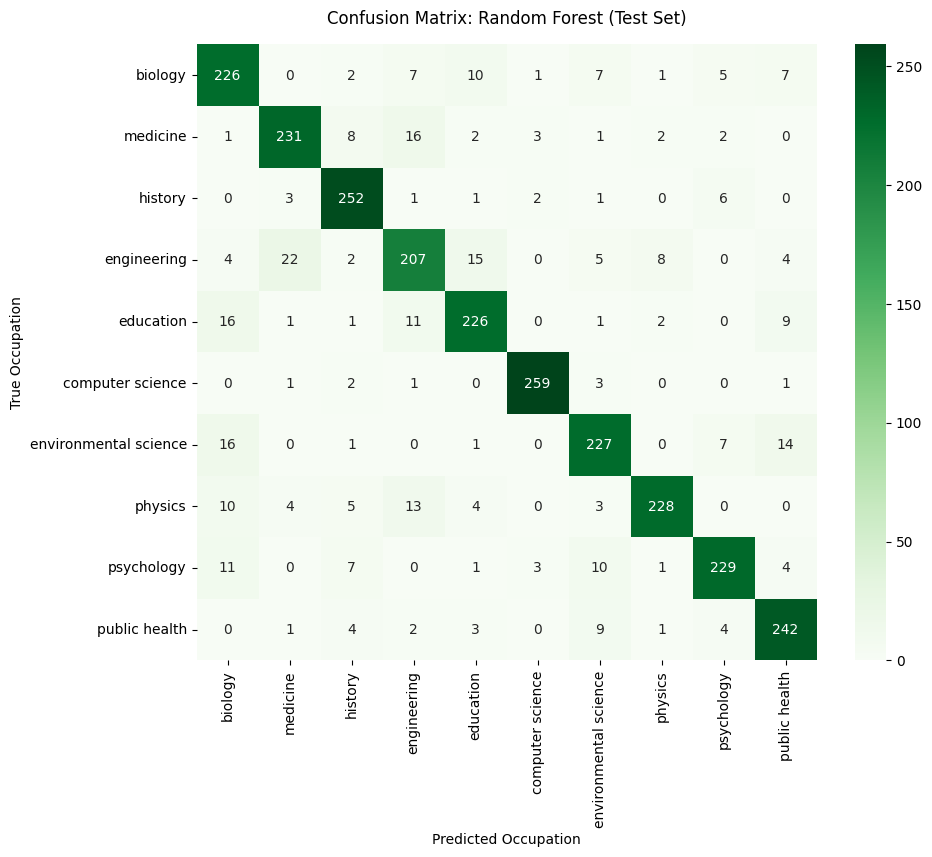

In [124]:
y_test_pred_rf = rf_config1.predict(X_test_tfidf_heavy)

acc_rf_test = accuracy_score(y_test_num, y_test_pred_rf)
f1_rf_test = f1_score(y_test_num, y_test_pred_rf, average='weighted')

print(f"Accuracy: {acc_rf_test:.4f} | Weighted F1: {f1_rf_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_rf, target_names=top_10_names))

cm_rf = confusion_matrix(y_test_num, y_test_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Random Forest (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## II. Logistic Regression (Best Configuration: 3)

Accuracy: 0.9182 | Weighted F1: 0.9182

Classification Report
                       precision    recall  f1-score   support

              biology       0.88      0.88      0.88       266
             medicine       0.94      0.92      0.93       266
              history       0.95      0.94      0.95       266
          engineering       0.89      0.89      0.89       267
            education       0.91      0.90      0.91       267
     computer science       0.99      0.99      0.99       267
environmental science       0.87      0.88      0.87       266
              physics       0.94      0.94      0.94       267
           psychology       0.91      0.92      0.92       266
        public health       0.90      0.93      0.91       266

             accuracy                           0.92      2664
            macro avg       0.92      0.92      0.92      2664
         weighted avg       0.92      0.92      0.92      2664



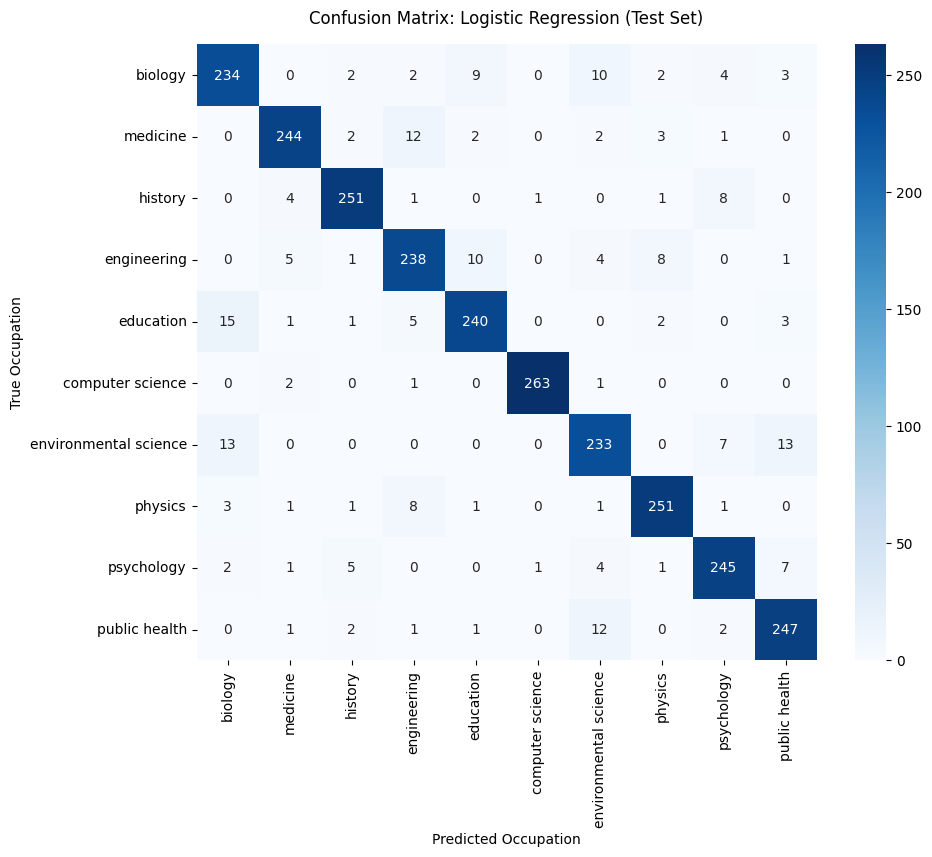

In [125]:
y_test_pred_lr = lr_config3.predict(X_test_tfidf_heavy)

acc_lr_test = accuracy_score(y_test_num, y_test_pred_lr)
f1_lr_test = f1_score(y_test_num, y_test_pred_lr, average='weighted')

print(f"Accuracy: {acc_lr_test:.4f} | Weighted F1: {f1_lr_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_lr, target_names=top_10_names))

cm = confusion_matrix(y_test_num, y_test_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Logistic Regression (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## III. Naive Bayes (Best Configuration: 1)

Accuracy: 0.9032 | Weighted F1: 0.9025

Classification Report
                       precision    recall  f1-score   support

              biology       0.92      0.79      0.85       266
             medicine       0.94      0.91      0.93       266
              history       0.90      0.95      0.93       266
          engineering       0.89      0.82      0.85       267
            education       0.85      0.93      0.89       267
     computer science       0.97      0.99      0.98       267
environmental science       0.89      0.84      0.86       266
              physics       0.92      0.91      0.92       267
           psychology       0.92      0.92      0.92       266
        public health       0.86      0.95      0.90       266

             accuracy                           0.90      2664
            macro avg       0.90      0.90      0.90      2664
         weighted avg       0.90      0.90      0.90      2664



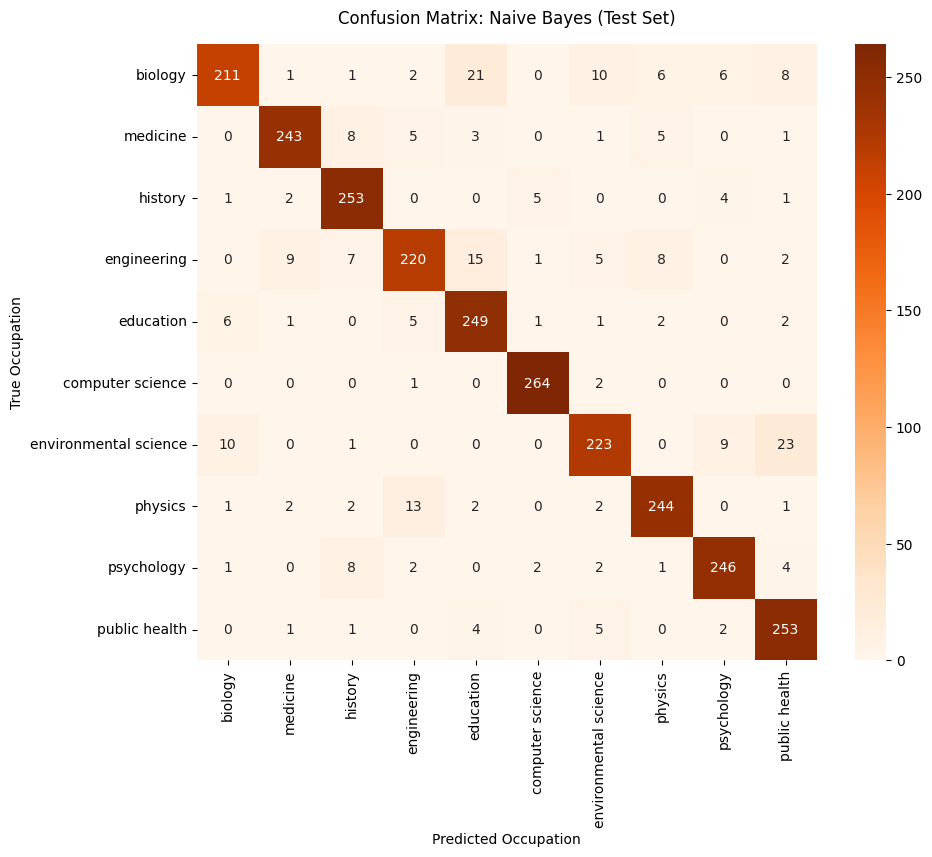

In [126]:
y_test_pred_nb = nb_config1.predict(X_test_tfidf_heavy)

acc_nb_test = accuracy_score(y_test_num, y_test_pred_nb)
f1_nb_test = f1_score(y_test_num, y_test_pred_nb, average='weighted')

print(f"Accuracy: {acc_nb_test:.4f} | Weighted F1: {f1_nb_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_nb, target_names=top_10_names))

cm_nb = confusion_matrix(y_test_num, y_test_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Naive Bayes (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## IV. SimpleRNN (Best Configuration: 3)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.5206 | Weighted F1: 0.5109

Classification Report
                       precision    recall  f1-score   support

              biology       0.52      0.28      0.37       266
             medicine       0.63      0.63      0.63       266
              history       0.69      0.70      0.69       266
          engineering       0.34      0.41      0.37       267
            education       0.41      0.70      0.52       267
     computer science       0.74      0.54      0.62       267
environmental science       0.61      0.50      0.55       266
              physics       0.40      0.59      0.48       267
           psychology       0.58      0.17      0.26       266
        public health       0.55      0.70      0.62       266

             accuracy                           0.52      2664
            macro avg       0.55      0.52      0.51      2664
         weighted avg       0.55      0.52      0.51      2664



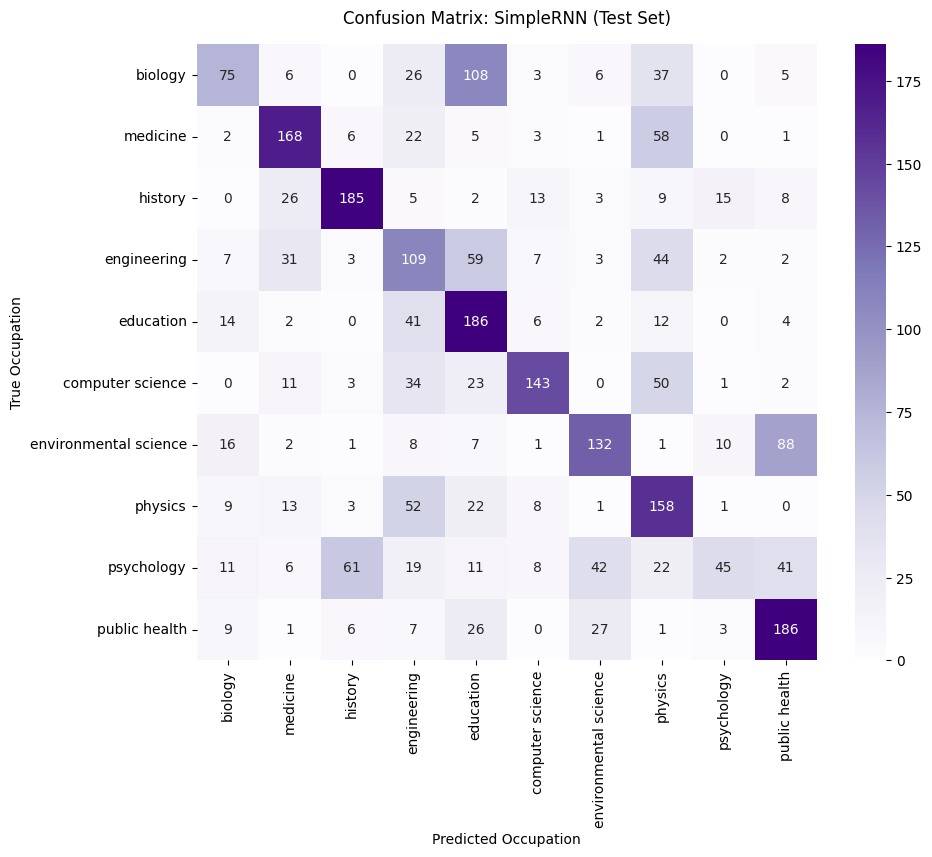

In [127]:
predictions_rnn_test = rnn_config3.predict(test_seq_heavy)
y_test_pred_rnn = np.argmax(predictions_rnn_test, axis=1)

acc_rnn_test = accuracy_score(y_test_num, y_test_pred_rnn)
f1_rnn_test = f1_score(y_test_num, y_test_pred_rnn, average='weighted')

print(f"Accuracy: {acc_rnn_test:.4f} | Weighted F1: {f1_rnn_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_rnn, target_names=top_10_names))

cm_rnn = confusion_matrix(y_test_num, y_test_pred_rnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Purples', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: SimpleRNN (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## V. GRU (Best Configuration: 2)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.9197 | Weighted F1: 0.9195

Classification Report
                       precision    recall  f1-score   support

              biology       0.86      0.92      0.89       266
             medicine       0.91      0.92      0.92       266
              history       0.96      0.92      0.94       266
          engineering       0.92      0.83      0.87       267
            education       0.89      0.93      0.90       267
     computer science       0.99      0.97      0.98       267
environmental science       0.94      0.85      0.89       266
              physics       0.94      0.96      0.95       267
           psychology       0.92      0.94      0.93       266
        public health       0.88      0.96      0.92       266

             accuracy                           0.92      2664
            macro avg       0.92      0.92      0.92      2664
         weighted avg       0.92      0.92      0.92      2664



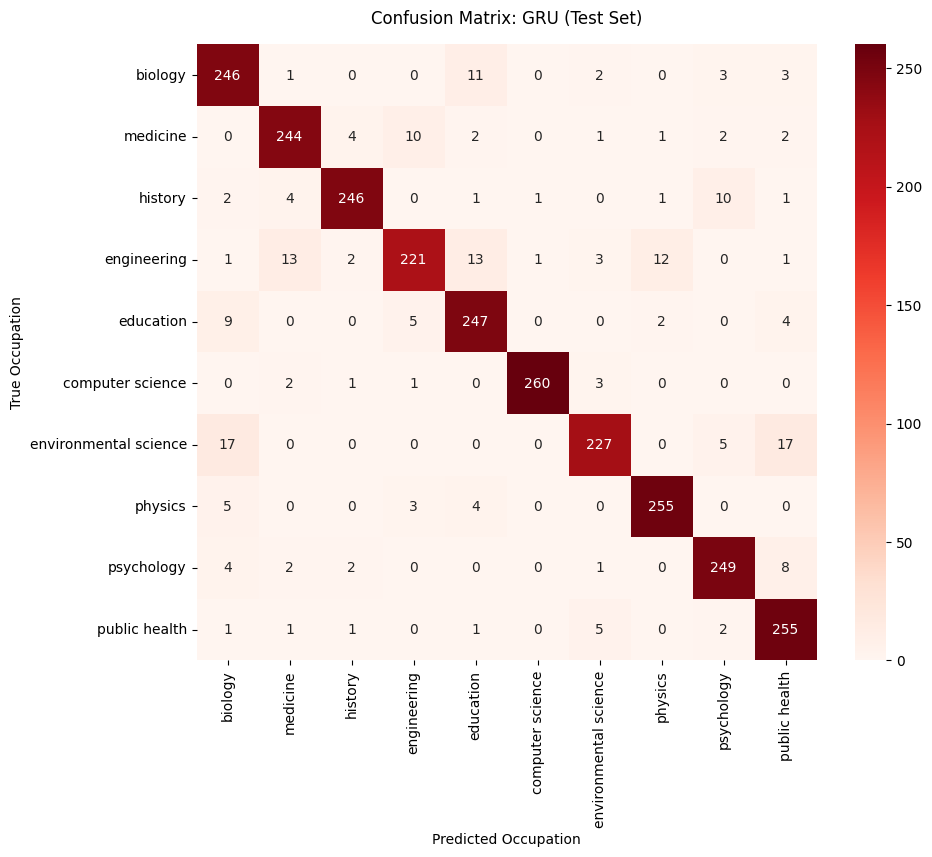

In [128]:
predictions_gru_test = gru_config2.predict(test_seq_heavy)
y_test_pred_gru = np.argmax(predictions_gru_test, axis=1)

acc_gru_test = accuracy_score(y_test_num, y_test_pred_gru)
f1_gru_test = f1_score(y_test_num, y_test_pred_gru, average='weighted')

print(f"Accuracy: {acc_gru_test:.4f} | Weighted F1: {f1_gru_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_gru, target_names=top_10_names))

cm_gru = confusion_matrix(y_test_num, y_test_pred_gru)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Reds', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: GRU (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## VI. LSTM (Best Configuration: 1)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.9002 | Weighted F1: 0.8999

Classification Report
                       precision    recall  f1-score   support

              biology       0.90      0.82      0.86       266
             medicine       0.96      0.81      0.88       266
              history       0.91      0.97      0.94       266
          engineering       0.82      0.87      0.85       267
            education       0.91      0.87      0.89       267
     computer science       0.98      0.98      0.98       267
environmental science       0.83      0.93      0.88       266
              physics       0.92      0.94      0.93       267
           psychology       0.89      0.89      0.89       266
        public health       0.88      0.92      0.90       266

             accuracy                           0.90      2664
            macro avg       0.90      0.90      0.90      2664
         weighted avg       0.90      0.90      0.90      2664



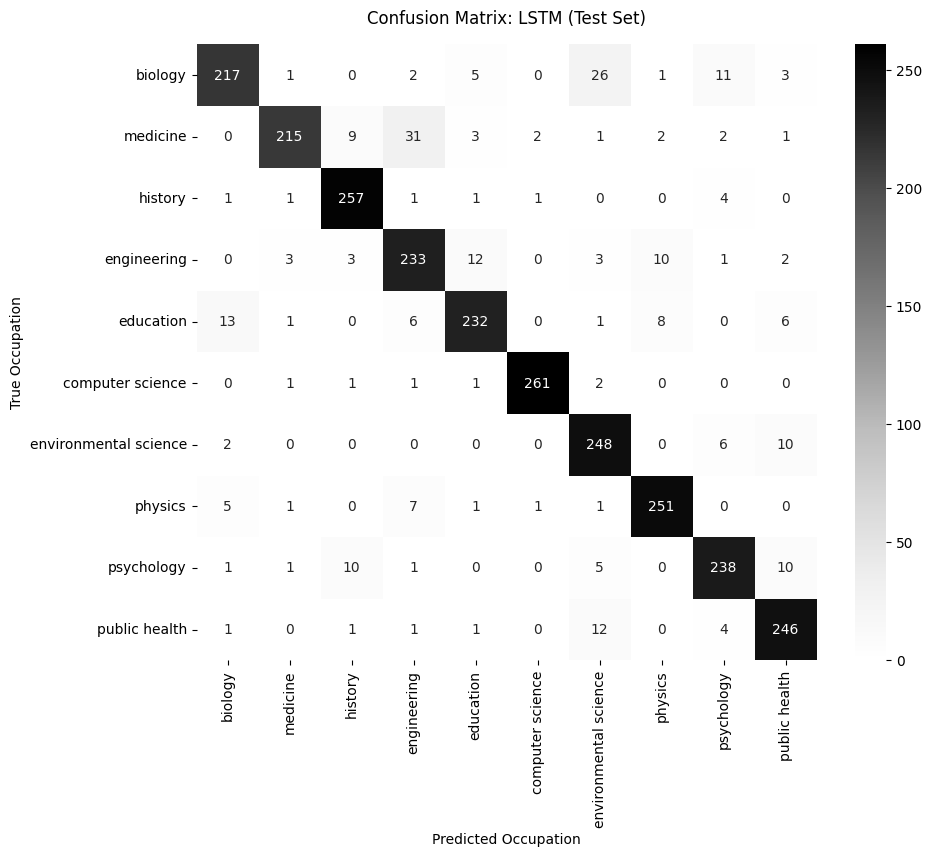

In [129]:
predictions_lstm_test = lstm_config1.predict(test_seq_heavy)
y_test_pred_lstm = np.argmax(predictions_lstm_test, axis=1)

acc_lstm_test = accuracy_score(y_test_num, y_test_pred_lstm)
f1_lstm_test = f1_score(y_test_num, y_test_pred_lstm, average='weighted')

print(f"Accuracy: {acc_lstm_test:.4f} | Weighted F1: {f1_lstm_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_lstm, target_names=top_10_names))

cm_lstm = confusion_matrix(y_test_num, y_test_pred_lstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greys', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: LSTM (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## VII. Bidirectional SimpleRNN (Best Configuration: 1)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy: 0.8626 | Weighted F1: 0.8621

Classification Report
                       precision    recall  f1-score   support

              biology       0.87      0.83      0.85       266
             medicine       0.89      0.88      0.89       266
              history       0.80      0.94      0.86       266
          engineering       0.84      0.85      0.84       267
            education       0.86      0.77      0.81       267
     computer science       0.97      0.96      0.96       267
environmental science       0.91      0.84      0.87       266
              physics       0.83      0.92      0.87       267
           psychology       0.82      0.76      0.79       266
        public health       0.87      0.87      0.87       266

             accuracy                           0.86      2664
            macro avg       0.86      0.86      0.86      2664
         weighted avg       0.86      0.86      0.86      2664



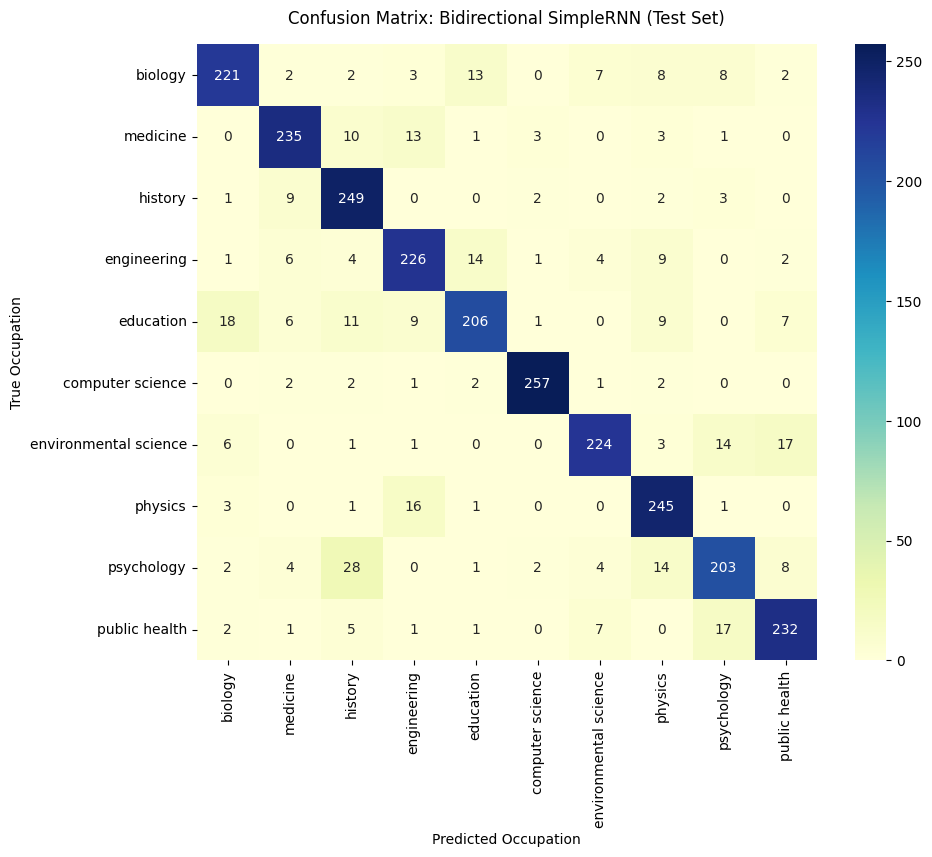

In [130]:
predictions_birnn_test = birnn_config1.predict(test_seq_heavy)
y_test_pred_birnn = np.argmax(predictions_birnn_test, axis=1)

acc_birnn_test = accuracy_score(y_test_num, y_test_pred_birnn)
f1_birnn_test = f1_score(y_test_num, y_test_pred_birnn, average='weighted')

print(f"Accuracy: {acc_birnn_test:.4f} | Weighted F1: {f1_birnn_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_birnn, target_names=top_10_names))

cm_birnn = confusion_matrix(y_test_num, y_test_pred_birnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_birnn, annot=True, fmt='d', cmap='YlGnBu', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Bidirectional SimpleRNN (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## VIII. Bidirectional GRU (Best Configuration: 2)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.9291 | Weighted F1: 0.9289

Classification Report
                       precision    recall  f1-score   support

              biology       0.95      0.85      0.90       266
             medicine       0.95      0.92      0.94       266
              history       0.93      0.94      0.94       266
          engineering       0.89      0.89      0.89       267
            education       0.88      0.94      0.91       267
     computer science       0.99      0.98      0.98       267
environmental science       0.94      0.90      0.92       266
              physics       0.91      0.97      0.94       267
           psychology       0.92      0.94      0.93       266
        public health       0.93      0.95      0.94       266

             accuracy                           0.93      2664
            macro avg       0.93      0.93      0.93      2664
         weighted avg       0.93      0.93      0.93      2664



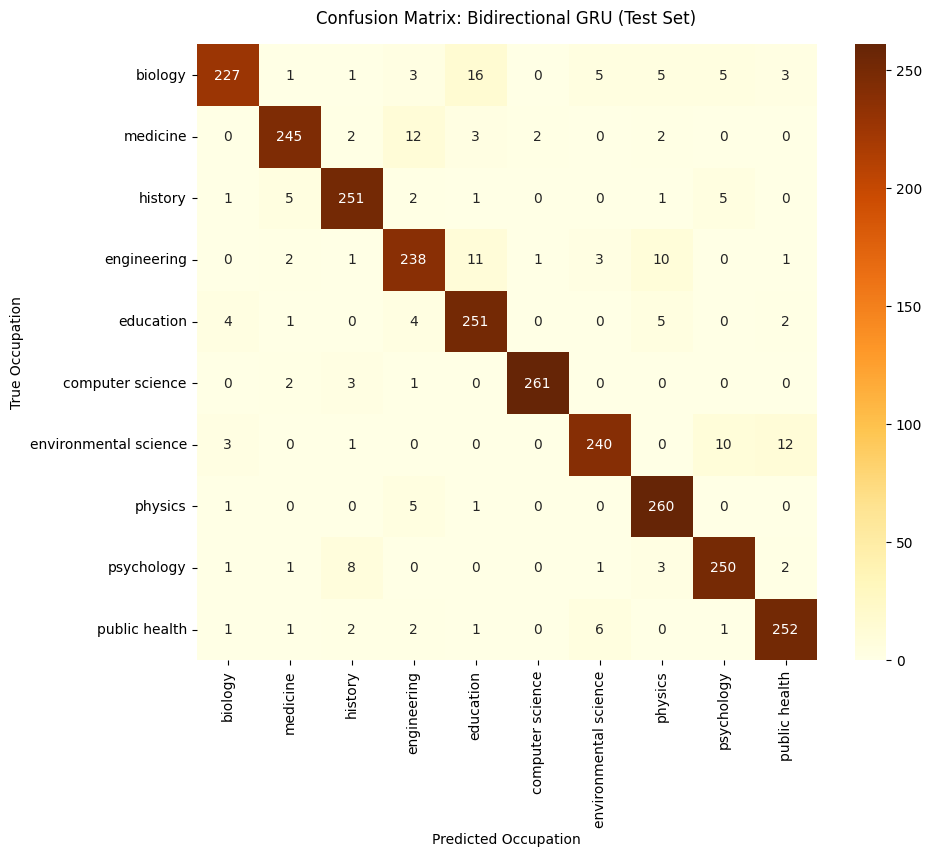

In [131]:
predictions_bigru_test = bigru_config2.predict(test_seq_heavy)
y_test_pred_bigru = np.argmax(predictions_bigru_test, axis=1)

acc_bigru_test = accuracy_score(y_test_num, y_test_pred_bigru)
f1_bigru_test = f1_score(y_test_num, y_test_pred_bigru, average='weighted')

print(f"Accuracy: {acc_bigru_test:.4f} | Weighted F1: {f1_bigru_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_bigru, target_names=top_10_names))

cm_bigru = confusion_matrix(y_test_num, y_test_pred_bigru)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bigru, annot=True, fmt='d', cmap='YlOrBr', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Bidirectional GRU (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## IX. Bidirectional LSTM (Best Configuration: 2)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.9129 | Weighted F1: 0.9130

Classification Report
                       precision    recall  f1-score   support

              biology       0.81      0.94      0.87       266
             medicine       0.89      0.95      0.92       266
              history       0.91      0.95      0.93       266
          engineering       0.91      0.85      0.88       267
            education       0.88      0.92      0.90       267
     computer science       0.97      0.98      0.98       267
environmental science       0.96      0.82      0.89       266
              physics       0.95      0.94      0.94       267
           psychology       0.96      0.87      0.92       266
        public health       0.91      0.92      0.92       266

             accuracy                           0.91      2664
            macro avg       0.92      0.91      0.91      2664
         weighted avg       0.92      0.91      0.91      2664



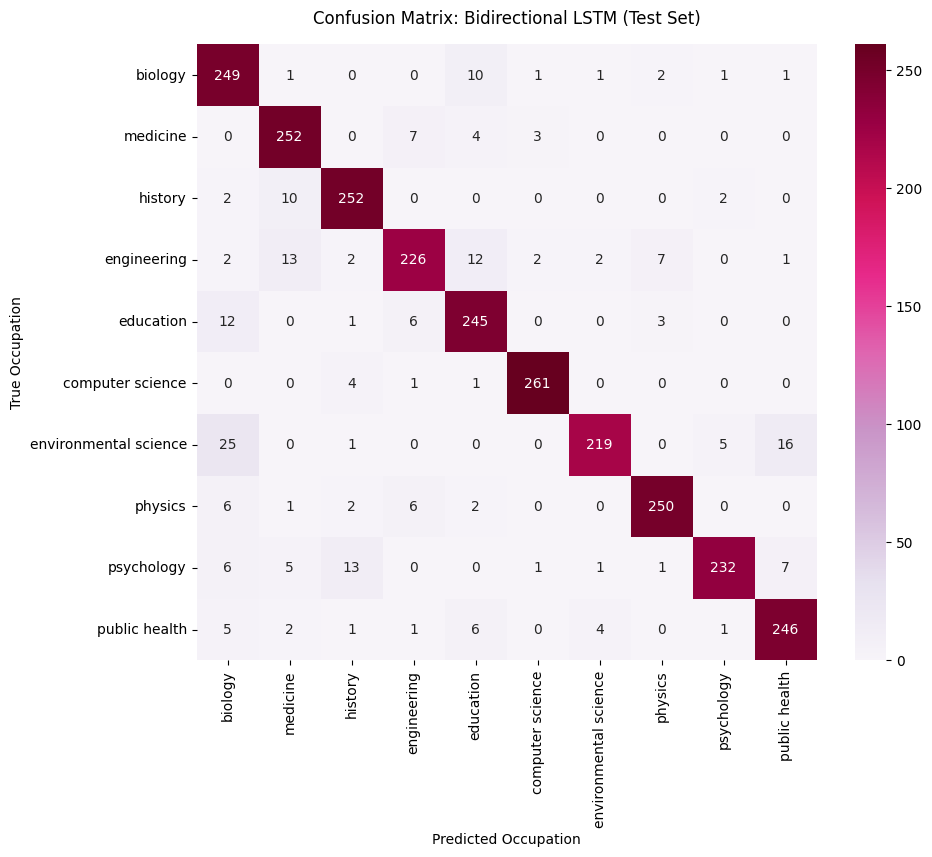

In [132]:
predictions_bilstm_test = bilstm_config2.predict(test_seq_heavy)
y_test_pred_bilstm = np.argmax(predictions_bilstm_test, axis=1)

acc_bilstm_test = accuracy_score(y_test_num, y_test_pred_bilstm)
f1_bilstm_test = f1_score(y_test_num, y_test_pred_bilstm, average='weighted')

print(f"Accuracy: {acc_bilstm_test:.4f} | Weighted F1: {f1_bilstm_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_bilstm, target_names=top_10_names))

cm_bilstm = confusion_matrix(y_test_num, y_test_pred_bilstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='PuRd', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Bidirectional LSTM (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## X. BERT Base (Best Configuration: 2)

Accuracy: 0.9505 | Weighted F1: 0.9505

Classification Report
                       precision    recall  f1-score   support

              biology       0.91      0.94      0.92       266
             medicine       0.96      0.96      0.96       266
              history       0.98      0.97      0.97       266
          engineering       0.93      0.92      0.92       267
            education       0.94      0.93      0.93       267
     computer science       1.00      0.99      0.99       267
environmental science       0.92      0.95      0.93       266
              physics       0.96      0.96      0.96       267
           psychology       0.97      0.94      0.95       266
        public health       0.95      0.95      0.95       266

             accuracy                           0.95      2664
            macro avg       0.95      0.95      0.95      2664
         weighted avg       0.95      0.95      0.95      2664



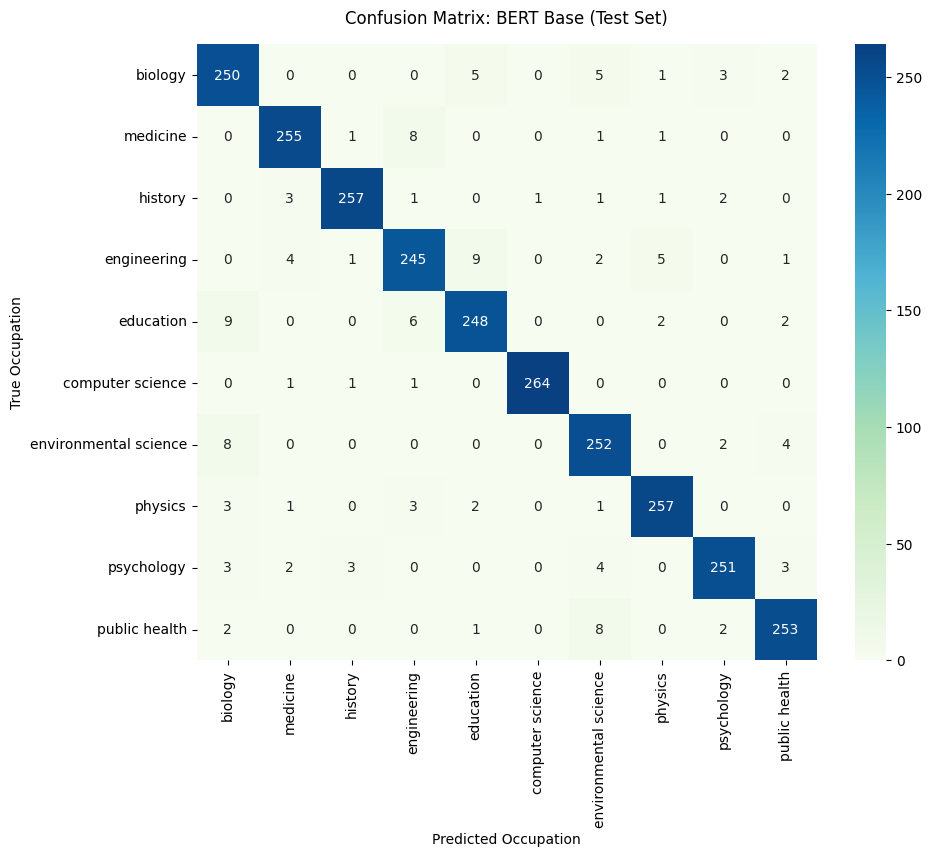

In [133]:
predictions_bert_test = trainer_2.predict(test_dataset_light)
y_test_pred_bert = np.argmax(predictions_bert_test.predictions, axis=1)

acc_bert_test = accuracy_score(y_test_num, y_test_pred_bert)
f1_bert_test = f1_score(y_test_num, y_test_pred_bert, average='weighted')

print(f"Accuracy: {acc_bert_test:.4f} | Weighted F1: {f1_bert_test:.4f}\n")

print("Classification Report")
print(classification_report(y_test_num, y_test_pred_bert, target_names=top_10_names))

cm_bert = confusion_matrix(y_test_num, y_test_pred_bert)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='GnBu', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: BERT Base (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

# 14. Final Model Comparison

## Final Test Set Performance

In [134]:
final_test_results = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Random Forest', 'Naive Bayes',
        'SimpleRNN', 'GRU', 'LSTM',
        'Bidirectional RNN', 'Bidirectional GRU', 'Bidirectional LSTM',
        'BERT Base (Light)'
    ],
    'Test Accuracy': [
        acc_lr_test, acc_rf_test, acc_nb_test,
        acc_rnn_test, acc_gru_test, acc_lstm_test,
        acc_birnn_test, acc_bigru_test, acc_bilstm_test,
        acc_bert_test
    ],
    'Test F1 Score': [
        f1_lr_test, f1_rf_test, f1_nb_test,
        f1_rnn_test, f1_gru_test, f1_lstm_test,
        f1_birnn_test, f1_bigru_test, f1_bilstm_test,
        f1_bert_test
    ]
})

final_test_results = final_test_results.sort_values(by='Test F1 Score', ascending=False).reset_index(drop=True)

print("Final Test Set Performance")

display(final_test_results)

Final Test Set Performance


,Model,Test Accuracy,Test F1 Score
0,BERT Base (Light),0.950450,0.950531
1,Bidirectional GRU,0.929054,0.928930
2,GRU,0.919670,0.919533
3,Logistic Regression,0.918168,0.918228
4,Bidirectional LSTM,0.912913,0.912962
5,Naive Bayes,0.903153,0.902479
6,LSTM,0.900150,0.899915
7,Random Forest,0.873498,0.873438
8,Bidirectional RNN,0.862613,0.862120
9,SimpleRNN,0.520646,0.510856


## Final Model Comparison: Weighted F1 Score on Test Set

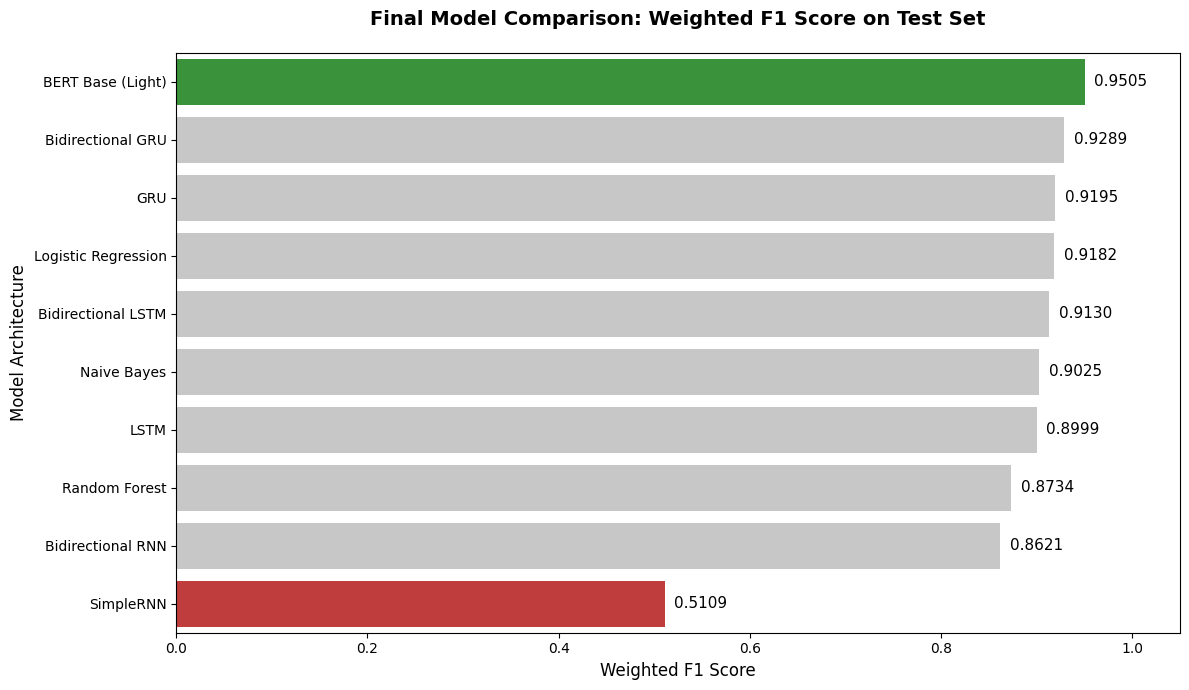

In [135]:
plt.figure(figsize=(12, 7))

colors = ['#2ca02c' if i == 0 else '#d62728' if i == len(final_test_results)-1 else '#c7c7c7' for i in range(len(final_test_results))]

sns.barplot(x='Test F1 Score', y='Model', data=final_test_results, hue='Model', palette=colors, legend=False)

for index, value in enumerate(final_test_results['Test F1 Score']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=11)

plt.title('Final Model Comparison: Weighted F1 Score on Test Set', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Weighted F1 Score', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

## Final Model Comparison: Accuracy on Test Set

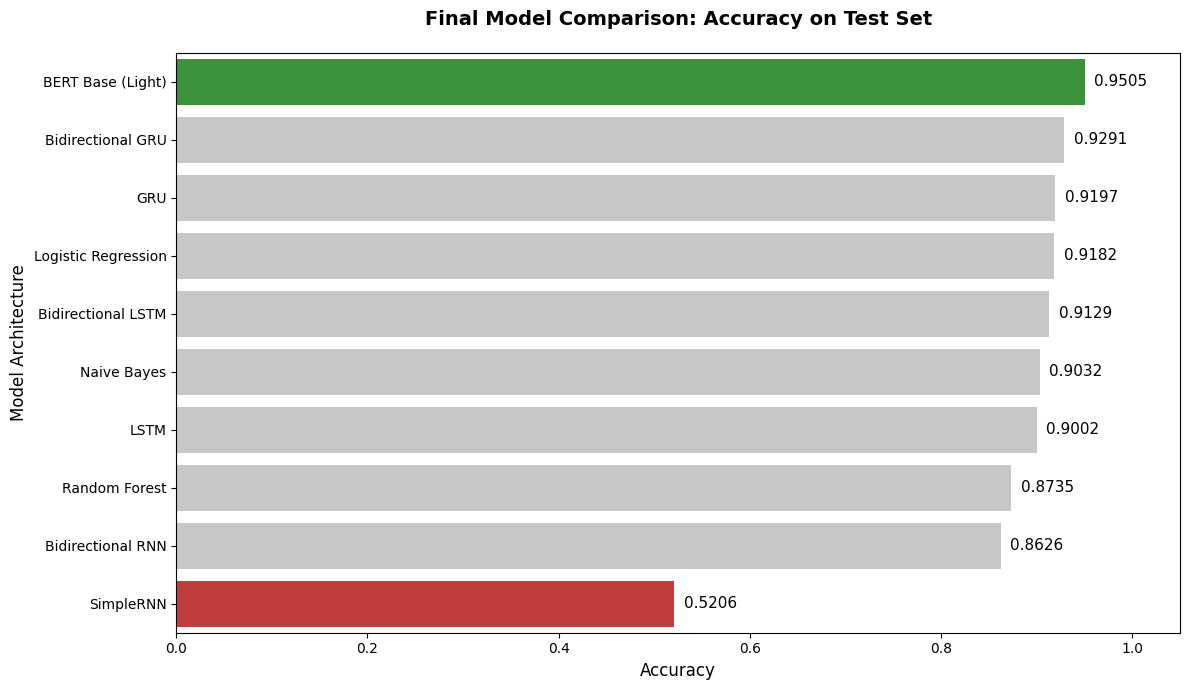

In [136]:
final_test_accuracy = final_test_results.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))

colors_acc = ['#2ca02c' if i == 0 else '#d62728' if i == len(final_test_accuracy)-1 else '#c7c7c7' for i in range(len(final_test_accuracy))]

sns.barplot(x='Test Accuracy', y='Model', data=final_test_accuracy, hue='Model', palette=colors_acc, legend=False)

for index, value in enumerate(final_test_accuracy['Test Accuracy']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=11)

plt.title('Final Model Comparison: Accuracy on Test Set', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

# 15. Ensemble of the Best Performing Models

## Soft Voting Ensemble

Ensemble Accuracy: 0.9535 | Ensemble Weighted F1: 0.9535

Ensemble Classification Report
                       precision    recall  f1-score   support

              biology       0.93      0.94      0.93       266
             medicine       0.96      0.95      0.95       266
              history       0.97      0.96      0.97       266
          engineering       0.92      0.92      0.92       267
            education       0.95      0.96      0.95       267
     computer science       1.00      0.99      0.99       267
environmental science       0.94      0.93      0.94       266
              physics       0.96      0.98      0.97       267
           psychology       0.97      0.95      0.96       266
        public health       0.95      0.96      0.96       266

             accuracy                           0.95      2664
            macro avg       0.95      0.95      0.95      2664
         weighted avg       0.95      0.95      0.95      2664



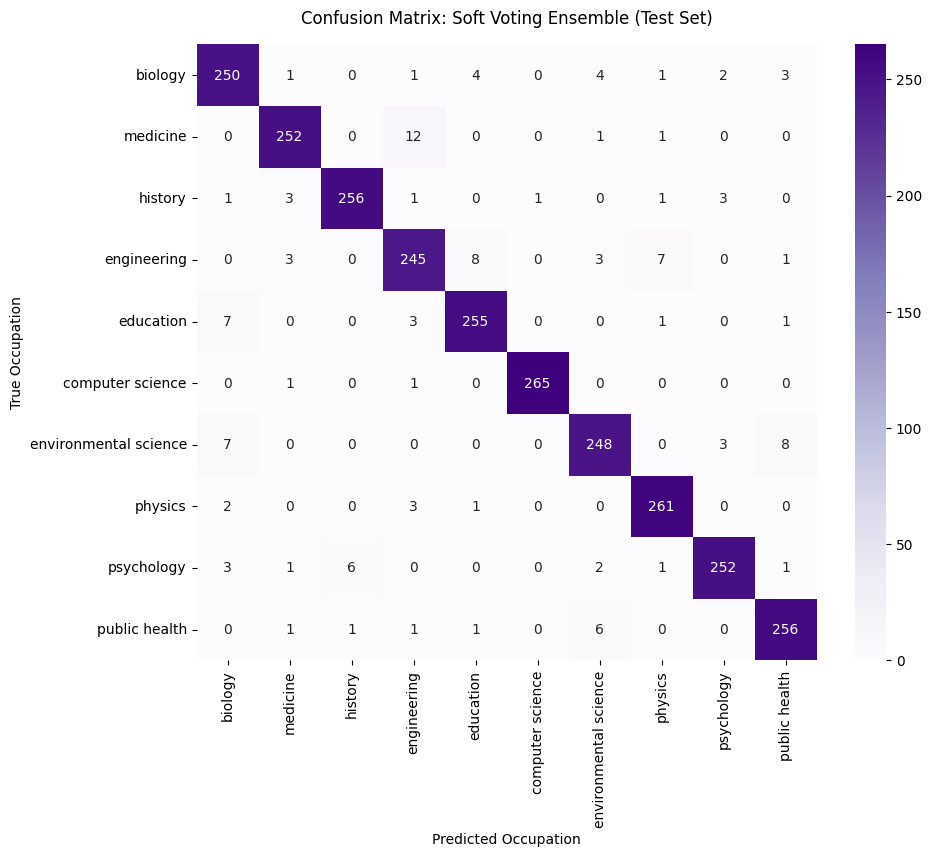

In [139]:
lr_probs = lr_config3.predict_proba(X_test_tfidf_heavy)

gru_probs = predictions_bigru_test

bert_probs = softmax(predictions_bert_test.predictions, axis=1)

ensemble_probs = (lr_probs + gru_probs + bert_probs) / 3.0

y_test_pred_ensemble = np.argmax(ensemble_probs, axis=1)

acc_ensemble_test = accuracy_score(y_test_num, y_test_pred_ensemble)
f1_ensemble_test = f1_score(y_test_num, y_test_pred_ensemble, average='weighted')

print(f"Ensemble Accuracy: {acc_ensemble_test:.4f} | Ensemble Weighted F1: {f1_ensemble_test:.4f}\n")

print("Ensemble Classification Report")
print(classification_report(y_test_num, y_test_pred_ensemble, target_names=top_10_names))

cm_ensemble = confusion_matrix(y_test_num, y_test_pred_ensemble)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', xticklabels=top_10_names, yticklabels=top_10_names)
plt.title('Confusion Matrix: Soft Voting Ensemble (Test Set)', pad=15)
plt.ylabel('True Occupation')
plt.xlabel('Predicted Occupation')
plt.show()

## Comparison of BERT Base and Soft Voting Ensemble

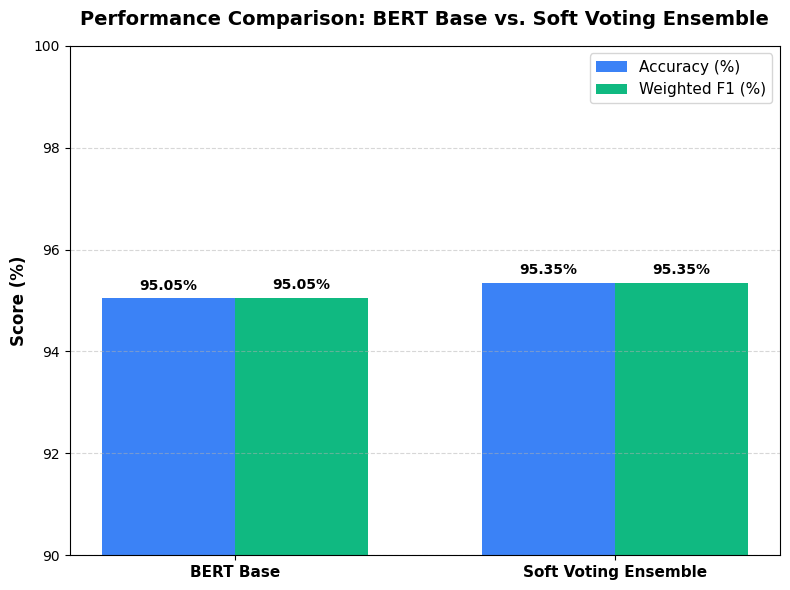

In [140]:
models = ['BERT Base', 'Soft Voting Ensemble']

accuracies = [acc_bert_test * 100, acc_ensemble_test * 100]
f1_scores = [f1_bert_test * 100, f1_ensemble_test * 100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', color='#3b82f6')
rects2 = ax.bar(x + width/2, f1_scores, width, label='Weighted F1 (%)', color='#10b981')

ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: BERT Base vs. Soft Voting Ensemble', fontsize=14, pad=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')

ax.set_ylim(90.0, 100.0)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()